# Import

In [1]:
import pandas as pd
import openpyxl

file = 'messy_billing_dataset.xlsx'

# See all sheet names
print(pd.ExcelFile(file).sheet_names)

clients       = pd.read_excel(file, sheet_name='Clients')
matters       = pd.read_excel(file, sheet_name='Matters')
staff         = pd.read_excel(file, sheet_name='Staff')
work_codes    = pd.read_excel(file, sheet_name='Work_Codes')
profiles      = pd.read_excel(file, sheet_name='Billing_Profiles')
invoices      = pd.read_excel(file, sheet_name='Invoices')
invoice_lines = pd.read_excel(file, sheet_name='Invoice_Lines')
payments      = pd.read_excel(file, sheet_name='Payments')
fx            = pd.read_excel(file, sheet_name='FX_Rates')

# Hourly_Tracker has 3 title rows above the real header, so skip them
time = pd.read_excel(file, sheet_name='Hourly_Tracker', header=3)

# Rate_Card has a 2-row header (year / currency) – load raw and reshape later
rate_card_raw = pd.read_excel(file, sheet_name='Rate_Card', header=None)

['README', 'Clients', 'Matters', 'Billing_Profiles', 'Rate_Card', 'Work_Codes', 'Staff', 'Hourly_Tracker', 'Invoices', 'Invoice_Lines', 'Payments', 'FX_Rates']


In [2]:
def inspect(df, name):
    print(f"=== {name}: {df.shape[0]} rows × {df.shape[1]} cols")
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'missing': df.isna().sum(),
        'unique': df.nunique(),
        'example': df.iloc[0],
    })
    display(summary)

for name, df in {'clients': clients, 'matters': matters, 'staff': staff,
                 'work_codes': work_codes, 'time': time, 'invoices': invoices,
                 'invoice_lines': invoice_lines, 'payments': payments}.items():
    inspect(df, name)

=== clients: 36 rows × 8 cols


,dtype,missing,unique,example
client_id,str,0,36,C2001
client_name,str,0,36,Orion Group
industry,str,0,10,Energy
billing_currency,str,0,6,USD
payment_terms,str,0,6,30 days
default_profile,str,0,8,HOURLY_CAP
vat_rate,float64,0,6,0.17
billing_contact_email,str,0,35,ap@orion.com


=== matters: 122 rows × 9 cols


,dtype,missing,unique,example
matter_id,str,0,122,M00001
client_id,str,0,36,C2001
matter_name,str,0,122,Engagement Luna-1
billing_profile,str,0,9,CONTINGENCY
practice_area,str,0,6,Tax
responsible_partner,str,0,4,E1059
open_date,datetime64[us],0,115,2025-05-08 00:00:00
close_date,datetime64[us],31,83,NaT
budget,int64,0,110,338000


=== staff: 61 rows × 7 cols


...

,dtype,missing,unique,example
invoice_no,str,0,2906,INV-50001
client_id,str,0,35,C2001
matter_id,str,0,121,M00001
billing_profile,str,0,8,CONTINGENCY
period,str,0,25,2024-01
invoice_date,datetime64[us],0,290,2024-02-12 00:00:00
currency,str,0,4,USD
fees,float64,0,2301,8595.45
adjustment,float64,0,241,0.0
adjustment_note,str,2318,3,NaN


=== invoice_lines: 24294 rows × 7 cols


,dtype,missing,unique,example
invoice_no,str,0,2906,INV-50001
line_no,int64,0,18,1
work_code,str,52,25,TAX-300
staff_level,str,0,7,Associate
hours,float64,0,1411,12.13
rate,float64,0,192,135.0
amount,float64,0,14671,1637.55


=== payments: 2286 rows × 6 cols


,dtype,missing,unique,example
payment_id,str,0,2286,P700000
invoice_ref,str,6,2274,INV-51545
pay_date,datetime64[us],0,733,2024-12-09 00:00:00
amount,float64,0,1674,48332.42
currency,str,0,4,ILS
method,str,0,5,Wire


# Data Cleaning

## Lookup tables

### Clients

In [3]:
clients_raw = clients.copy()  
issues = []                   

def log_issue(table, column, issue, rows, action):
    issues.append({'table': table, 'column': column, 'issue': issue,
                   'rows_affected': rows, 'action': action})

In [4]:
print("Exact duplicate rows:", clients.duplicated().sum())
print("Duplicate client_ids:", clients['client_id'].duplicated().sum())

# Same company, different spelling/ID: normalise the name before comparing
clients['name_key'] = (clients['client_name']
                       .str.lower()
                       .str.replace(r'[^a-z]', '', regex=True))  # drop spaces, dots, etc.
dupes = clients[clients['name_key'].duplicated(keep=False)]
display(dupes)

Exact duplicate rows: 0
Duplicate client_ids: 0


,client_id,client_name,industry,billing_currency,payment_terms,default_profile,vat_rate,billing_contact_email,name_key
3,C2004,Keystone Group,Non-profit,GBP,Net 30,BLENDED,0.19,ap@keystone.com,keystonegroup
35,C2099,keystone group,Non-profit,GBP,Net 30,BLENDED,0.19,ap@keystone.com,keystonegroup


In [5]:
print("C2099 in matters:", (matters['client_id'] == 'C2099').sum())
print("C2099 in invoices:", (invoices['client_id'] == 'C2099').sum())

C2099 in matters: 0
C2099 in invoices: 0


In [6]:
client_map = {'C2099': 'C2004'}
clients = clients[clients['client_id'] != 'C2099'].drop(columns='name_key')
log_issue('Clients', 'client_id', 'Duplicate client C2099 = C2004', 1, 'Removed')

In [7]:
print(clients['billing_currency'].value_counts())

billing_currency
USD    16
GBP     7
EUR     6
ILS     4
usd     1
$       1
Name: count, dtype: int64


In [8]:
clients['billing_currency'] = (clients['billing_currency']
                               .str.strip().str.upper()
                               .replace({'$': 'USD'}))
print(clients['billing_currency'].value_counts())   # should be only USD, GBP, EUR, ILS
log_issue('Clients', 'billing_currency', "'usd' and '$' instead of USD", 2, 'Standardised to ISO codes')

billing_currency
USD    18
GBP     7
EUR     6
ILS     4
Name: count, dtype: int64


In [9]:
bad_email = ~clients['billing_contact_email'].str.match(r'^[^@\s]+@[^@\s]+\.[a-z]+$')
display(clients[bad_email])   # ap@@atlas.com

clients['billing_contact_email'] = clients['billing_contact_email'].str.replace('@@', '@')
print("Invalid emails left:", (~clients['billing_contact_email'].str.match(r'^[^@\s]+@[^@\s]+\.[a-z]+$')).sum())
log_issue('Clients', 'billing_contact_email', 'Double @@', 1, 'Fixed to single @')

,client_id,client_name,industry,billing_currency,payment_terms,default_profile,vat_rate,billing_contact_email
6,C2007,Atlas plc,Real Estate,GBP,Net 45,HOURLY_DISC,0.19,ap@@atlas.com


Invalid emails left: 0


In [11]:
print(clients['vat_rate'].describe())
display(clients[clients['vat_rate'] > 1])   

count    35.000000
mean      0.626286
std       2.850209
min       0.000000
25%       0.170000
50%       0.190000
75%       0.195000
max      17.000000
Name: vat_rate, dtype: float64


,client_id,client_name,industry,billing_currency,payment_terms,default_profile,vat_rate,billing_contact_email
15,C2016,Sterling GmbH,Tech,USD,NET30,FIXED_FEE,17.0,ap@sterling.com


In [12]:
clients.loc[clients['vat_rate'] > 1, 'vat_rate'] /= 100
log_issue('Clients', 'vat_rate', 'Stored as percent (17) not fraction (0.17)', 1, 'Divided by 100')

In [13]:
print(clients['payment_terms'].value_counts())

def terms_to_days(t):
    t = str(t).lower()
    if 'receipt' in t:
        return 0
    return int(''.join(ch for ch in t if ch.isdigit()))

clients['payment_terms_days'] = clients['payment_terms'].apply(terms_to_days)
display(clients[['payment_terms', 'payment_terms_days']].drop_duplicates())
log_issue('Clients', 'payment_terms', 'Inconsistent spellings', len(clients), 'Added payment_terms_days column')

payment_terms
NET30             9
Net 30            7
Net 45            7
Due on receipt    5
30 days           4
Net 60            3
Name: count, dtype: int64


,payment_terms,payment_terms_days
0,30 days,30
1,Net 30,30
2,Net 60,60
4,NET30,30
5,Due on receipt,0
6,Net 45,45


In [14]:
print(clients.shape)                             
print(clients['client_id'].is_unique)           
print(clients.isna().sum().sum())               
print(set(matters['client_id']) - set(clients['client_id']))   

(35, 9)
True
0
{'C2999'}


In [15]:
pd.DataFrame(issues)  

,table,column,issue,rows_affected,action
0,Clients,client_id,Duplicate client C2099 = C2004,1,Removed
1,Clients,billing_currency,'usd' and '$' instead of USD,2,Standardised to ISO codes
2,Clients,billing_contact_email,Double @@,1,Fixed to single @
3,Clients,vat_rate,Stored as percent (17) not fraction (0.17),1,Divided by 100
4,Clients,payment_terms,Inconsistent spellings,35,Added payment_terms_days column


### Matters

In [16]:
matters_raw = matters.copy()

print("Duplicate matter_ids:", matters['matter_id'].duplicated().sum())
print("Exact duplicate rows:", matters.duplicated().sum())
print(matters['billing_profile'].value_counts())
print(matters['practice_area'].value_counts())

Duplicate matter_ids: 0
Exact duplicate rows: 0
billing_profile
HOURLY_DISC        28
HOURLY_STD         19
HOURLY_CAP         16
FIXED_FEE          15
BLENDED            14
RETAINER           11
PRO_BONO           10
CONTINGENCY         8
HOURLY_STANDARD     1
Name: count, dtype: int64
practice_area
Tax              29
Litigation       23
Technology       18
Advisory         18
Due Diligence    17
Audit            17
Name: count, dtype: int64


In [17]:
valid_profiles = set(profiles['profile_code'])
display(matters[~matters['billing_profile'].isin(valid_profiles)])

matters['billing_profile'] = matters['billing_profile'].replace({'HOURLY_STANDARD': 'HOURLY_STD'})
print("Invalid profiles left:", (~matters['billing_profile'].isin(valid_profiles)).sum())
log_issue('Matters', 'billing_profile', "'HOURLY_STANDARD' is not a valid code", 1, 'Mapped to HOURLY_STD')

,matter_id,client_id,matter_name,billing_profile,practice_area,responsible_partner,open_date,close_date,budget
4,M00005,C2002,Matter Sierra-5,HOURLY_STANDARD,Audit,E1028,2024-07-12,NaT,538000


Invalid profiles left: 0


In [18]:
orphans = matters[~matters['client_id'].isin(clients['client_id'])]
display(orphans)
print("Invoices for this matter:", (invoices['matter_id'].isin(orphans['matter_id'])).sum())

,matter_id,client_id,matter_name,billing_profile,practice_area,responsible_partner,open_date,close_date,budget
10,M00011,C2999,Matter Luna-11,HOURLY_DISC,Technology,E1028,2024-01-12,2025-05-16,517000


Invoices for this matter: 0


In [19]:
# not clear who is this client C2999, but we will keep the matter and flag it
matters['dq_unknown_client'] = ~matters['client_id'].isin(clients['client_id'])
log_issue('Matters', 'client_id', 'Client C2999 not in Clients table', 1, 'Kept, flagged')

In [20]:
bad_dates = matters[matters['close_date'] < matters['open_date']]
display(bad_dates)   # M00021: closed before it opened

matters['dq_close_before_open'] = matters['close_date'] < matters['open_date']
log_issue('Matters', 'close_date', 'Close date before open date', 1, 'Kept, flagged')

,matter_id,client_id,matter_name,billing_profile,practice_area,responsible_partner,open_date,close_date,budget,dq_unknown_client
20,M00021,C2006,Project Nova-21,HOURLY_STD,Tax,E1059,2024-08-18,2024-07-19,430000,False


In [21]:
m = matters.merge(staff[['staff_id', 'level', 'termination_date']],
                  left_on='responsible_partner', right_on='staff_id', how='left')
print(m['level'].value_counts())                          
left = m[m['termination_date'].notna()]
print(left.groupby('responsible_partner').size())        

level
Partner    122
Name: count, dtype: int64
responsible_partner
E1038    34
dtype: int64


In [22]:
log_issue('Matters', 'responsible_partner', 'Partner E1038 left 2024-06-08 but owns 34 matters', 34, 'Kept, reported as finding')

In [23]:
print(matters['budget'].describe())
print("Zero/negative budgets:", (matters['budget'] <= 0).sum())

count       122.000000
mean     296704.918033
std      178267.080182
min       24000.000000
25%      131000.000000
50%      272500.000000
75%      469000.000000
max      598000.000000
Name: budget, dtype: float64
Zero/negative budgets: 0


In [24]:
print(matters.shape, matters['matter_id'].is_unique)
pd.DataFrame(issues)

(122, 11) True


,table,column,issue,rows_affected,action
0,Clients,client_id,Duplicate client C2099 = C2004,1,Removed
1,Clients,billing_currency,'usd' and '$' instead of USD,2,Standardised to ISO codes
2,Clients,billing_contact_email,Double @@,1,Fixed to single @
3,Clients,vat_rate,Stored as percent (17) not fraction (0.17),1,Divided by 100
4,Clients,payment_terms,Inconsistent spellings,35,Added payment_terms_days column
5,Matters,billing_profile,'HOURLY_STANDARD' is not a valid code,1,Mapped to HOURLY_STD
6,Matters,client_id,Client C2999 not in Clients table,1,"Kept, flagged"
7,Matters,close_date,Close date before open date,1,"Kept, flagged"
8,Matters,responsible_partner,Partner E1038 left 2024-06-08 but owns 34 matters,34,"Kept, reported as finding"


### Staff

In [25]:
staff_raw = staff.copy()

print("Duplicate staff_ids:", staff['staff_id'].duplicated().sum())
print("Exact duplicate rows:", staff.duplicated().sum())
print(staff['level'].value_counts())
print(staff['office'].value_counts())

Duplicate staff_ids: 0
Exact duplicate rows: 0
level
Associate            21
Senior Associate     10
Analyst               9
Senior Manager        7
Manager               6
Paralegal/Support     4
Partner               4
Name: count, dtype: int64
office
London       15
Tel Aviv     13
New York      9
Berlin        9
NYC           8
New York      7
Name: count, dtype: int64


In [26]:
print(staff['office'].unique())   # repr shows the trailing space

staff['office'] = staff['office'].str.strip().replace({'NYC': 'New York'})
print(staff['office'].value_counts())   # should be 4 offices
log_issue('Staff', 'office', "'NYC' and trailing spaces vs 'New York'", 15, 'Standardised to New York')

<StringArray>
['London', 'Tel Aviv', 'New York', 'New York ', 'Berlin', 'NYC']
Length: 6, dtype: str
office
New York    24
London      15
Tel Aviv    13
Berlin       9
Name: count, dtype: int64


In [27]:
staff['name_key'] = staff['name'].str.lower().str.strip()
display(staff[staff['name_key'].duplicated(keep=False)].sort_values('name_key'))

,staff_id,name,level,office,hire_date,termination_date,cost_rate_usd,name_key
17,E1018,Sofia Davis,Associate,Tel Aviv,2020-03-09,2025-06-19,76.35,sofia davis
42,E1043,Sofia Davis,Analyst,New York,2021-04-06,NaT,57.24,sofia davis
7,E1008,Yael Miller,Manager,New York,2023-02-09,NaT,118.88,yael miller
60,E1099,YAEL MILLER,Manager,New York,2023-02-09,NaT,118.88,yael miller


In [28]:
print("E1099 in time entries:", (time['staff_id'] == 'E1099').sum())
print("E1099 as partner on matters:", (matters['responsible_partner'] == 'E1099').sum())

E1099 in time entries: 0
E1099 as partner on matters: 0


In [29]:
staff_map = {'E1099': 'E1008'}
staff = staff[staff['staff_id'] != 'E1099'].drop(columns='name_key')
log_issue('Staff', 'staff_id', 'E1099 duplicate of E1008 (same person, uppercase name)', 1, 'Removed')
log_issue('Staff', 'name', 'Two different people named Sofia Davis (E1018, E1043)', 2, 'Kept both; join on staff_id only')

In [ ]:
rate_levels = set(rate_card_raw.iloc[5:, 0])
print(set(staff['level']) - rate_levels)   

set()


In [31]:
print("Terminated before hired:", (staff['termination_date'] < staff['hire_date']).sum())
print("Currently employed:", staff['termination_date'].isna().sum(), "| Left:", staff['termination_date'].notna().sum())
display(staff.groupby('level')['cost_rate_usd'].agg(['min', 'mean', 'max']).sort_values('mean'))

Terminated before hired: 0
Currently employed: 47 | Left: 13


,min,mean,max
level,,,
Paralegal/Support,36.69,39.622500,43.43
Analyst,50.63,54.374444,59.80
Associate,63.27,70.394286,76.67
Senior Associate,81.04,90.112000,96.93
Manager,111.67,118.778000,127.72
Senior Manager,136.63,151.888571,164.88
Partner,191.94,211.100000,229.35


In [32]:
print(staff.shape, staff['staff_id'].is_unique)  
pd.DataFrame(issues)

(60, 7) True


,table,column,issue,rows_affected,action
0,Clients,client_id,Duplicate client C2099 = C2004,1,Removed
1,Clients,billing_currency,'usd' and '$' instead of USD,2,Standardised to ISO codes
2,Clients,billing_contact_email,Double @@,1,Fixed to single @
3,Clients,vat_rate,Stored as percent (17) not fraction (0.17),1,Divided by 100
4,Clients,payment_terms,Inconsistent spellings,35,Added payment_terms_days column
5,Matters,billing_profile,'HOURLY_STANDARD' is not a valid code,1,Mapped to HOURLY_STD
6,Matters,client_id,Client C2999 not in Clients table,1,"Kept, flagged"
7,Matters,close_date,Close date before open date,1,"Kept, flagged"
8,Matters,responsible_partner,Partner E1038 left 2024-06-08 but owns 34 matters,34,"Kept, reported as finding"
9,Staff,office,'NYC' and trailing spaces vs 'New York',15,Standardised to New York


### Work_Codes

In [33]:
work_codes_raw = work_codes.copy()

print("Duplicate codes:", work_codes['work_code'].duplicated().sum())
print(work_codes['active'].value_counts())
print(work_codes['billing_class'].value_counts())
print(work_codes['retired_on'].tolist())

Duplicate codes: 1
active
Y       21
N        2
yes      1
TRUE     1
Name: count, dtype: int64
billing_class
Billable              19
Non-billable           4
Partially Billable     1
Pass-through           1
Name: count, dtype: int64
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, '2024-06-30', '31/03/2024', nan]


In [34]:
display(work_codes[work_codes['work_code'].duplicated(keep=False)])

,work_code,practice_area,description,billing_class,active,retired_on
6,TAX-300,Tax,Tax return preparation,Billable,Y,NaN
24,TAX-300,Tax,Tax compliance,Billable,Y,NaN


In [35]:
work_codes = work_codes.drop_duplicates('work_code', keep='first')
log_issue('Work_Codes', 'work_code', "TAX-300 defined twice ('Tax return preparation' / 'Tax compliance')", 1, 'Kept first definition')

In [36]:
work_codes['active'] = (work_codes['active'].astype(str).str.strip().str.upper()
                        .isin(['Y', 'YES', 'TRUE', '1']))
print(work_codes['active'].value_counts())   # 22 True, 2 False
log_issue('Work_Codes', 'active', 'Mixed booleans (Y / yes / TRUE / N)', 2, 'Converted to True/False')

active
True     22
False     2
Name: count, dtype: int64


In [37]:
work_codes['retired_on'] = pd.to_datetime(work_codes['retired_on'], dayfirst=True, format='mixed')
display(work_codes[work_codes['retired_on'].notna()])
log_issue('Work_Codes', 'retired_on', 'Mixed date formats', 2, 'Parsed to datetime')

,work_code,practice_area,description,billing_class,active,retired_on
22,ADV-105,Advisory,General advisory (legacy),Billable,False,2024-06-30
23,AUD-205,Audit,Fieldwork (old code),Billable,False,2024-03-31


In [39]:
work_codes['billable_share'] = work_codes['billing_class'].map({
    'Billable': 1.0,
    'Partially Billable': 0.5,   
    'Non-billable': 0.0,         
    'Pass-through': 0.0,         
})
print(work_codes['billable_share'].isna().sum())  

0


In [40]:
print(work_codes.shape, work_codes['work_code'].is_unique)   # 24 rows, True
display(work_codes)
pd.DataFrame(issues)

(24, 7) True


,work_code,practice_area,description,billing_class,active,retired_on,billable_share
0,ADV-100,Advisory,General advisory,Billable,True,NaT,1.0
1,ADV-110,Advisory,Strategy workshop,Billable,True,NaT,1.0
2,ADV-120,Advisory,Board presentation prep,Billable,True,NaT,1.0
3,AUD-200,Audit,Fieldwork,Billable,True,NaT,1.0
4,AUD-210,Audit,Controls testing,Billable,True,NaT,1.0
5,AUD-220,Audit,Audit report drafting,Billable,True,NaT,1.0
6,TAX-300,Tax,Tax return preparation,Billable,True,NaT,1.0
7,TAX-310,Tax,Tax planning,Billable,True,NaT,1.0
8,TAX-320,Tax,Transfer pricing,Billable,True,NaT,1.0
9,LIT-400,Litigation,Document review,Billable,True,NaT,1.0


,table,column,issue,rows_affected,action
0,Clients,client_id,Duplicate client C2099 = C2004,1,Removed
1,Clients,billing_currency,'usd' and '$' instead of USD,2,Standardised to ISO codes
2,Clients,billing_contact_email,Double @@,1,Fixed to single @
3,Clients,vat_rate,Stored as percent (17) not fraction (0.17),1,Divided by 100
4,Clients,payment_terms,Inconsistent spellings,35,Added payment_terms_days column
5,Matters,billing_profile,'HOURLY_STANDARD' is not a valid code,1,Mapped to HOURLY_STD
6,Matters,client_id,Client C2999 not in Clients table,1,"Kept, flagged"
7,Matters,close_date,Close date before open date,1,"Kept, flagged"
8,Matters,responsible_partner,Partner E1038 left 2024-06-08 but owns 34 matters,34,"Kept, reported as finding"
9,Staff,office,'NYC' and trailing spaces vs 'New York',15,Standardised to New York


### Billing_Profiles

In [41]:
profiles_raw = profiles.copy()
display(profiles)
print(profiles['monthly_cap'].tolist())   # '40,000 USD' is text, not a number

,profile_code,profile_type,description,rate_multiplier,monthly_cap,monthly_retainer,fixed_fee_per_milestone,blended_rate,billing_increment_hrs,notes
0,HOURLY_STD,Hourly,Standard hourly at rate card,1.00,NaN,NaN,NaN,NaN,0.10,NaN
1,HOURLY_DISC,Hourly,Hourly with negotiated discount,0.85,NaN,NaN,NaN,NaN,0.10,NaN
2,HOURLY_CAP,Hourly Capped,"Hourly, monthly fee cap",1.00,"40,000 USD",NaN,NaN,NaN,0.25,NaN
3,RETAINER,Retainer,"Monthly retainer, hours drawn down, overage bi...",0.90,NaN,15000.0,NaN,NaN,0.25,NaN
4,FIXED_FEE,Fixed Fee,Fixed fee per milestone,NaN,NaN,NaN,60000.0,NaN,NaN,NaN
5,BLENDED,Blended Rate,Single blended rate regardless of level,NaN,NaN,NaN,NaN,325.0,0.10,NaN
6,CONTINGENCY,Contingency,% of recovery + reduced hourly,0.50,NaN,NaN,NaN,NaN,0.10,plus 22% of recovered amount
7,PRO_BONO,Pro Bono,"No charge, time tracked",0.00,NaN,NaN,NaN,NaN,0.10,NaN


[nan, nan, '40,000 USD', nan, nan, nan, nan, nan]


In [42]:
profiles['cap_currency'] = profiles['monthly_cap'].str.extract(r'([A-Z]{3})')
profiles['monthly_cap'] = pd.to_numeric(
    profiles['monthly_cap'].str.replace(r'[^\d.]', '', regex=True), errors='coerce')
log_issue('Billing_Profiles', 'monthly_cap', "Stored as text '40,000 USD'", 1, 'Split into numeric cap + cap_currency')

In [43]:
profiles['contingency_pct'] = pd.to_numeric(
    profiles['notes'].str.extract(r'(\d+)%')[0], errors='coerce') / 100
log_issue('Billing_Profiles', 'notes', 'Contingency 22% only in free-text notes', 1, 'Extracted to contingency_pct')

In [45]:
valid = set(profiles['profile_code'])
print("Matters:", set(matters['billing_profile']) - valid)        
print("Clients:", set(clients['default_profile']) - valid)
print("Invoices:", set(invoices['billing_profile']) - valid)

Matters: set()
Clients: set()
Invoices: set()


### Rate_Card

In [ ]:
rate_card = pd.read_excel(file, sheet_name='Rate_Card', header=[3, 4], index_col=0)
rate_card = rate_card.stack([0, 1], future_stack=True).reset_index()
rate_card.columns = ['staff_level', 'fiscal_year', 'currency', 'rate']
rate_card['fiscal_year'] = rate_card['fiscal_year'].str[2:].astype(int)   # 'FY2024' → 2024

In [47]:
rate_card['rate'] = pd.to_numeric(rate_card['rate'], errors='coerce')   # 'TBD' → NaN
rate_card.loc[rate_card['rate'].isna(), 'rate'] = 193

mask = (rate_card['staff_level'] == 'Manager') & (rate_card['currency'] == 'GBP') & (rate_card['fiscal_year'] == 2025)
rate_card.loc[mask, 'rate'] = 362

In [48]:
check = rate_card.pivot_table(index=['staff_level', 'currency'], columns='fiscal_year', values='rate')
print((check[2025] / check[2024]).sort_values().tail(3))   # one ratio ≈ 10.6 stands out

staff_level        currency
Paralegal/Support  EUR         1.062016
Analyst            EUR         1.062176
Manager            GBP         1.064706
dtype: float64


### FX_Rates

In [49]:
fx_raw = fx.copy()

print("Duplicate month/currency pairs:", fx.duplicated(['month', 'currency']).sum())
print(fx.groupby('currency')['month'].count())    # EUR 24, GBP 24, ILS 23 → one missing
print(fx.groupby('currency')['usd_per_unit'].agg(['min', 'max']))   # sanity: EUR ~1.1, GBP ~1.25, ILS ~0.27

Duplicate month/currency pairs: 0
currency
EUR    24
GBP    24
ILS    23
Name: month, dtype: int64
             min     max
currency                
EUR       1.0451  1.1302
GBP       1.2160  1.3127
ILS       0.2603  0.2795


In [50]:
full = pd.MultiIndex.from_product([sorted(fx['month'].unique()), ['EUR', 'GBP', 'ILS']],
                                  names=['month', 'currency'])
fx = fx.set_index(['month', 'currency']).reindex(full).reset_index()
display(fx[fx['usd_per_unit'].isna()])   # 2025-03 ILS

fx['usd_per_unit'] = fx.groupby('currency')['usd_per_unit'].transform(lambda s: s.interpolate())
log_issue('FX_Rates', 'usd_per_unit', 'ILS 2025-03 missing', 1, 'Interpolated between Feb and Apr')

,month,currency,usd_per_unit
44,2025-03,ILS,NaN


In [51]:
usd = pd.DataFrame({'month': sorted(fx['month'].unique()), 'currency': 'USD', 'usd_per_unit': 1.0})
fx = pd.concat([fx, usd], ignore_index=True)

In [52]:
print("FX ends:", fx['month'].max(),
      "| Invoices end:", invoices['period'].max(),
      "| Payments end:", payments['pay_date'].max().strftime('%Y-%m'))

FX ends: 2025-12 | Invoices end: 2026-01 | Payments end: 2026-05


In [53]:
last = fx[fx['month'] == '2025-12']
fx = pd.concat([fx, last.assign(month='2026-01'), last.assign(month='2026-02')], ignore_index=True)
log_issue('FX_Rates', 'month', 'Table ends 2025-12; invoices/payments run to 2026-02', 2, 'Carried Dec-2025 rates forward')

In [ ]:
print(fx.shape)                                              
print(fx['usd_per_unit'].isna().sum())                       
print(fx.duplicated(['month', 'currency']).sum())            

(104, 3)
0
0


In [133]:
last = fx[fx['month'] == '2025-12']
extra = [last.assign(month=m) for m in ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05']]
fx = pd.concat([fx] + extra, ignore_index=True)

## Big Tables

### Hourly_Tracker.

In [55]:
time_raw = time.copy()
time['source_row'] = time.index + 5    # Excel row number, so any row can be traced back
print(time.shape)

(40400, 11)


In [56]:
# dates issue '02/26/2025', '01-Aug-25', '20240201'
import re

def parse_work_date(value, entered):
    if pd.isna(value):
        return pd.NaT
    if not isinstance(value, str):                       # already a real date
        return pd.Timestamp(value)
    s = value.strip()
    if re.fullmatch(r'\d{8}', s):                        # 20241112
        return pd.to_datetime(s, format='%Y%m%d')
    if re.fullmatch(r'\d{1,2}-[A-Za-z]{3}-\d{2}', s):    # 09-Oct-25
        return pd.to_datetime(s, format='%d-%b-%y')
    if re.fullmatch(r'\d{2}/\d{2}/\d{4}', s):            # dd/mm or mm/dd
        options = [pd.to_datetime(s, format=f, errors='coerce') for f in ('%d/%m/%Y', '%m/%d/%Y')]
        options = [d for d in options if pd.notna(d)]
        if len(options) == 1 or pd.isna(entered):
            return options[0]
        # prefer the date closest to entered_on, and not after it
        return min(options, key=lambda d: abs((entered - d).days) + (100 if d > entered else 0))
    return pd.NaT

time['entered_on'] = pd.to_datetime(time['entered_on'])
text_dates = time['work_date'].apply(lambda x: isinstance(x, str)).sum()
time['work_date'] = [parse_work_date(v, e) for v, e in zip(time['work_date'], time['entered_on'])]

print("Unparsed dates:", time['work_date'].isna().sum())
print(time['work_date'].min(), "→", time['work_date'].max())
log_issue('Hourly_Tracker', 'work_date', 'Dates as text in 4 formats, incl. ambiguous dd/mm vs mm/dd', int(text_dates),
          'Parsed; ambiguous ones resolved using entered_on')

Unparsed dates: 104
2024-01-01 00:00:00 → 2026-01-03 00:00:00


In [57]:
# hours as text 

print(time['hours'][time['hours'].apply(lambda x: isinstance(x, str))].sample(10, random_state=1).tolist())

def parse_hours(v):
    if pd.isna(v):
        return float('nan')
    if not isinstance(v, str):
        return float(v)
    s = v.strip().lower()
    if s.endswith('min'):
        return round(float(s.replace('min', '')) / 60, 2)
    s = re.sub(r'\s*(hrs|h)$', '', s).replace(',', '.')
    return float(s)

n_text = time['hours'].apply(lambda x: isinstance(x, str)).sum()
time['hours'] = time['hours'].apply(parse_hours)
print(time['hours'].describe())
log_issue('Hourly_Tracker', 'hours', "Hours as text ('2.1 hrs', '141 min', '2,78')", int(n_text), 'Converted to decimal hours')

['1.81 hrs', '1.04h', '1.8h', '2.28h', '108 min', '2.26h', '35 min', '147 min', '5.1 hrs', '0.95 hrs']
count    40149.000000
mean         4.907171
std         48.447526
min         -6.510000
25%          1.210000
50%          2.060000
75%          3.260000
max       2080.070000
Name: hours, dtype: float64


In [63]:
print("> 24h:", (time['hours'] > 24).sum())
print(time.loc[time['hours'] > 24, 'hours'].head(10).tolist()) 

> 24h: 104
[208.007, 115.89200000000001, 90.131, 100.15, 107.949, 97.365, 101.318, 109.42999999999999, 106.6, 110.40299999999999]


In [64]:
over = time['hours'] > 24
time.loc[over, 'hours'] /= 10
log_issue('Hourly_Tracker', 'hours', '>24h in one entry (misplaced decimal)', int(over.sum()), 'Divided by 10')

time['dq_negative_hours'] = time['hours'] < 0
time['dq_missing_hours'] = time['hours'].isna()
time['dq_exactly_9h'] = time['hours'] == 9
print("Negative:", time['dq_negative_hours'].sum(),
      "| Missing:", time['dq_missing_hours'].sum(),
      "| Exactly 9.00h:", time['dq_exactly_9h'].sum())

Negative: 120 | Missing: 251 | Exactly 9.00h: 150


In [65]:
print(time['hours'].round(2).value_counts().head(5))

hours
1.36    158
1.27    154
9.00    150
1.09    147
1.14    141
Name: count, dtype: int64


In [67]:
is_sub = time['entry_id'].astype(str).str.startswith('SUBTOTAL')
display(time[is_sub].head(3))
print("Subtotal rows:", is_sub.sum())
print("Hours incl. subtotals:", pd.to_numeric(time['hours'], errors='coerce').sum().round())

time = time[~is_sub].copy()
print("Hours after removal:", pd.to_numeric(time['hours'], errors='coerce').sum().round())
log_issue('Hourly_Tracker', 'entry_id', 'Weekly SUBTOTAL rows inside the data', int(is_sub.sum()), 'Removed')

,entry_id,work_date,staff_id,matter_id,work_code,hours,billable_flag,narrative,entered_on,approval_status,source_row,dq_negative_hours,dq_missing_hours,dq_exactly_9h
833,SUBTOTAL week 1/2024,NaT,NaN,NaN,NaN,20.8007,NaN,NaN,NaT,NaN,838,False,False,False
1295,SUBTOTAL week 2/2024,NaT,NaN,NaN,NaN,11.5892,NaN,NaN,NaT,NaN,1300,False,False,False
1676,SUBTOTAL week 3/2024,NaT,NaN,NaN,NaN,9.0131,NaN,NaN,NaT,NaN,1681,False,False,False


Subtotal rows: 104
Hours incl. subtotals: 97428.0
Hours after removal: 96449.0


In [68]:
dup = time.drop(columns='source_row').duplicated()
print("Exact duplicate rows:", dup.sum())
time = time[~dup].copy()
log_issue('Hourly_Tracker', '(row)', 'Exact duplicate rows', int(dup.sum()), 'Removed')

Exact duplicate rows: 350


In [70]:
# standardise staff IDs

def norm_staff(x):
    if pd.isna(x): return x
    s = str(x).strip().upper()
    s = s if s.startswith('E') else 'E' + s          # '1004' → 'E1004'
    return staff_map.get(s, s)                        # E1099 → E1008

def norm_matter(x):
    if pd.isna(x): return x
    s = str(x).strip().upper()
    m = re.fullmatch(r'M(\d+)', s)
    return f"M{int(m.group(1)):05d}" if m else s      # 'm00015' → 'M00015', 'M0012' → 'M00012'

def norm_code(x):
    if pd.isna(x): return x
    s = str(x).strip().upper().replace(' ', '-')      # 'AUD 200' → 'AUD-200'
    s = re.sub(r'^([A-Z]+)(\d)', r'\1-\2', s)         # 'ADV100'  → 'ADV-100'
    prefix, _, num = s.partition('-')
    return f"{prefix}-{num.replace('O', '0')}" if num else s   # 'TAX-3OO' → 'TAX-300'

for col, fn in [('staff_id', norm_staff), ('matter_id', norm_matter), ('work_code', norm_code)]:
    before = time[col].copy()
    time[col] = time[col].apply(fn)
    changed = (before.notna() & (before != time[col])).sum()
    log_issue('Hourly_Tracker', col, 'Inconsistent formatting', int(changed), 'Normalised')
    print(col, "fixed:", changed)

staff_id fixed: 50
matter_id fixed: 56
work_code fixed: 115


In [71]:
time['dq_unknown_staff']  = ~time['staff_id'].isin(staff['staff_id'])
time['dq_unknown_matter'] = ~time['matter_id'].isin(set(matters['matter_id']) | {'INTERNAL'})
time['dq_unknown_code']   = ~time['work_code'].isin(work_codes['work_code'])

for c, col in [('dq_unknown_staff', 'staff_id'), ('dq_unknown_matter', 'matter_id'), ('dq_unknown_code', 'work_code')]:
    print(col, time.loc[time[c], col].value_counts(dropna=False).to_dict())

staff_id {'E9999': 38, nan: 33}
matter_id {'M99999': 36, 'TBD': 32, nan: 28}
work_code {nan: 57, 'XYZ-000': 28}


In [72]:
print(time['billable_flag'].value_counts(dropna=False))

time['billable_flag'] = (time['billable_flag'].astype(str).str.strip().str.upper()
    .map({'Y': True, 'YES': True, 'TRUE': True, '1': True,
          'N': False, 'NO': False, 'FALSE': False, '0': False}))
time['approval_status'] = time['approval_status'].str.strip().str.title()

print(time['billable_flag'].value_counts(dropna=False))
print(time['approval_status'].value_counts())

billable_flag
Y       36270
N        3374
NaN        47
0          41
TRUE       39
No         37
Yes        37
n          35
y          34
1          32
Name: count, dtype: int64
billable_flag
True     36412
False     3487
NaN         47
Name: count, dtype: int64
approval_status
Approved    35476
Pending      3283
Rejected     1187
Name: count, dtype: int64


In [73]:
# hidden dublicates 
same = ['work_date', 'staff_id', 'matter_id', 'work_code', 'hours', 'narrative']
time['dq_possible_double_entry'] = time.duplicated(subset=same, keep='first') & time['hours'].notna()
print("Probable double entries:", time['dq_possible_double_entry'].sum())
display(time[time.duplicated(subset=same, keep=False)].sort_values(same).head(6))

Probable double entries: 200


,entry_id,work_date,staff_id,matter_id,work_code,hours,billable_flag,narrative,entered_on,approval_status,source_row,dq_negative_hours,dq_missing_hours,dq_exactly_9h,dq_unknown_staff,dq_unknown_matter,dq_unknown_code,dq_possible_double_entry
27,T0039618,2024-01-01,E1003,M00037,IT-610,1.44,True,Research: TP benchmarking,2024-01-01,Pending,32,False,False,False,False,False,False,False
352,T0000029,2024-01-01,E1003,M00037,IT-610,1.44,True,Research: TP benchmarking,2024-01-01,Pending,357,False,False,False,False,False,False,True
536,T0000098,2024-01-02,E1042,INTERNAL,BD-920,2.85,False,Analysis of working capital,2024-01-07,Approved,541,False,False,False,False,False,False,False
583,T0039615,2024-01-02,E1042,INTERNAL,BD-920,2.85,False,Analysis of working capital,2024-01-07,Approved,588,False,False,False,False,False,False,True
612,T0039628,2024-01-03,E1012,M00109,ADV-120,1.67,True,Call with client re VAT position,2024-01-05,Approved,617,False,False,False,False,False,False,False
640,T0000253,2024-01-03,E1012,M00109,ADV-120,1.67,True,Call with client re VAT position,2024-01-05,Approved,645,False,False,False,False,False,False,True


In [74]:
log_issue('Hourly_Tracker', '(row)', 'Same staff/date/matter/code/hours/narrative under a different entry_id',
          int(time['dq_possible_double_entry'].sum()), 'Kept, flagged as probable double entry; excluded from analysis')

In [75]:
time = time.merge(work_codes[['work_code', 'billing_class', 'billable_share', 'retired_on']], on='work_code', how='left')
time = time.merge(staff[['staff_id', 'level', 'hire_date', 'termination_date']], on='staff_id', how='left')

time['dq_billable_conflict'] = (time['billing_class'] == 'Non-billable') & (time['billable_flag'] == True)
time['dq_retired_code'] = time['retired_on'].notna() & (time['work_date'] > time['retired_on'])
time['dq_outside_employment'] = ((time['work_date'] < time['hire_date']) |
                                 (time['termination_date'].notna() & (time['work_date'] > time['termination_date'])))
time['dq_entered_before_work'] = time['entered_on'] < time['work_date']

print(time.filter(like='dq_').sum())

dq_negative_hours           119
dq_missing_hours            250
dq_exactly_9h               149
dq_unknown_staff             71
dq_unknown_matter            96
dq_unknown_code              85
dq_possible_double_entry    200
dq_billable_conflict        211
dq_retired_code             149
dq_outside_employment        56
dq_entered_before_work       87
dtype: int64


In [76]:
exclude = ['dq_negative_hours', 'dq_missing_hours', 'dq_unknown_staff',
           'dq_unknown_matter', 'dq_unknown_code', 'dq_possible_double_entry']
time['use_in_analysis'] = ~time[exclude].any(axis=1) & time['work_date'].notna()

# billable hours = hours × share (travel 50%) × flag, and 0 if the code is non-billable
time['billable_hours'] = (time['hours'] * time['billable_share'].fillna(0)
                          * time['billable_flag'].fillna(False).astype(float))
time.loc[time['dq_billable_conflict'], 'billable_hours'] = 0

print(time.shape, "| usable rows:", time['use_in_analysis'].sum())
print("Total hours:", time.loc[time['use_in_analysis'], 'hours'].sum().round(),
      "| Billable:", time.loc[time['use_in_analysis'], 'billable_hours'].sum().round())

(39946, 30) | usable rows: 39128
Total hours: 94839.0 | Billable: 84352.0


In [77]:
flag_descriptions = {
    'dq_negative_hours':       ('hours', 'Negative hours (sign error or reversal?)', 'Kept, flagged; excluded'),
    'dq_missing_hours':        ('hours', 'Blank hours', 'Kept, flagged; excluded'),
    'dq_exactly_9h':           ('hours', 'Unusual spike of exactly 9.00h entries (possible default)', 'Kept, flagged for review'),
    'dq_unknown_staff':        ('staff_id', 'Staff ID not in Staff (E9999 / blank)', 'Kept, flagged; excluded'),
    'dq_unknown_matter':       ('matter_id', 'Matter ID not in Matters (M99999 / TBD / blank)', 'Kept, flagged; excluded'),
    'dq_unknown_code':         ('work_code', 'Work code not in Work_Codes (XYZ-000 / blank)', 'Kept, flagged; excluded'),
    'dq_billable_conflict':    ('billable_flag', 'Marked billable but code is non-billable (ADM/TRN/BD/PTO)', 'Kept, treated as non-billable'),
    'dq_retired_code':         ('work_code', 'Retired code used after retirement date', 'Kept, flagged'),
    'dq_outside_employment':   ('work_date', 'Time logged before hire or after termination', 'Kept, flagged'),
    'dq_entered_before_work':  ('entered_on', 'Entry created before the work date', 'Kept, flagged'),
}
for flag, (col, desc, action) in flag_descriptions.items():
    log_issue('Hourly_Tracker', col, desc, int(time[flag].sum()), action)

In [78]:
pd.DataFrame(issues).query("table == 'Hourly_Tracker'")

,table,column,issue,rows_affected,action
19,Hourly_Tracker,work_date,"Dates as text in 4 formats, incl. ambiguous dd...",407,Parsed; ambiguous ones resolved using entered_on
20,Hourly_Tracker,hours,"Hours as text ('2.1 hrs', '141 min', '2,78')",298,Converted to decimal hours
21,Hourly_Tracker,hours,>24h in one entry (misplaced decimal),165,Divided by 10
22,Hourly_Tracker,hours,>24h in one entry (misplaced decimal),104,Divided by 10
23,Hourly_Tracker,entry_id,Weekly SUBTOTAL rows inside the data,104,Removed
24,Hourly_Tracker,(row),Exact duplicate rows,350,Removed
25,Hourly_Tracker,staff_id,Inconsistent formatting,50,Normalised
26,Hourly_Tracker,matter_id,Inconsistent formatting,56,Normalised
27,Hourly_Tracker,work_code,Inconsistent formatting,115,Normalised
28,Hourly_Tracker,(row),Same staff/date/matter/code/hours/narrative un...,200,"Kept, flagged as probable double entry; exclud..."


In [132]:
last = fx[fx['month'] == '2025-12']
extra = [last.assign(month=m) for m in ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05']]
fx = pd.concat([fx] + extra, ignore_index=True)

### Invoices

In [80]:
invoices_raw = invoices.copy()
print(invoices.shape)
print("Duplicate invoice_no:", invoices['invoice_no'].duplicated().sum())
print("Exact duplicate rows:", invoices.duplicated().sum())

(2918, 14)
Duplicate invoice_no: 12
Exact duplicate rows: 12


In [81]:
invoices = invoices.drop_duplicates().copy()
print("Duplicate invoice_no left:", invoices['invoice_no'].duplicated().sum())   # 0
log_issue('Invoices', '(row)', 'Exact duplicate invoice rows', 12, 'Removed')

Duplicate invoice_no left: 0


In [82]:
print(invoices['status'].value_counts())      # 'paid' vs 'Paid'
invoices['status'] = invoices['status'].str.strip().str.title()
log_issue('Invoices', 'status', "Case variants ('paid')", 255, 'Title-cased')

invoices['billing_profile'] = invoices['billing_profile'].replace({'HOURLY_STANDARD': 'HOURLY_STD'})
print(invoices['status'].value_counts())

status
Paid              1732
Outstanding        422
Partially Paid     300
paid               254
Disputed           107
Written Off         91
Name: count, dtype: int64
status
Paid              1986
Outstanding        422
Partially Paid     300
Disputed           107
Written Off         91
Name: count, dtype: int64


In [83]:
# Check that invoice client/profile matches the matter's client/profile
chk = invoices.merge(matters[['matter_id', 'client_id', 'billing_profile']],
                     on='matter_id', how='left', suffixes=('', '_matter'))
print("Invoice client ≠ matter's client:", (chk['client_id'] != chk['client_id_matter']).sum())
print("Invoice profile ≠ matter's profile:", (chk['billing_profile'] != chk['billing_profile_matter']).sum())
print("Unknown clients:", (~invoices['client_id'].isin(clients['client_id'])).sum())

Invoice client ≠ matter's client: 0
Invoice profile ≠ matter's profile: 0
Unknown clients: 0


In [84]:
# Flag invoices with mismatched client/profile, but keep them for now
invoices = invoices.merge(clients[['client_id', 'vat_rate', 'billing_currency', 'payment_terms_days']],
                          on='client_id', how='left')

invoices['dq_subtotal_mismatch'] = (invoices['subtotal'] - (invoices['fees'] + invoices['adjustment'])).abs() > 0.01
invoices['dq_tax_mismatch']      = (invoices['tax'] - (invoices['subtotal'] * invoices['vat_rate']).round(2)).abs() > 0.02
invoices['dq_total_mismatch']    = (invoices['total'] - (invoices['subtotal'] + invoices['tax'])).abs() > 0.01

print(invoices[['dq_subtotal_mismatch', 'dq_tax_mismatch', 'dq_total_mismatch']].sum())
display(invoices[invoices['dq_total_mismatch']][['invoice_no', 'subtotal', 'tax', 'total']].head())

dq_subtotal_mismatch    22
dq_tax_mismatch          0
dq_total_mismatch       37
dtype: int64


,invoice_no,subtotal,tax,total
28,INV-50029,8212.20,1396.07,9608.28
45,INV-50046,9678.42,1645.33,11323.76
110,INV-50111,14805.87,2961.17,18767.04
157,INV-50158,15517.68,3103.54,18620.72
218,INV-50219,5490.58,933.40,6423.99


In [85]:
log_issue('Invoices', 'subtotal', 'subtotal ≠ fees + adjustment', int(invoices['dq_subtotal_mismatch'].sum()), 'Kept, flagged')
log_issue('Invoices', 'total', 'total ≠ subtotal + tax', int(invoices['dq_total_mismatch'].sum()), 'Kept, flagged')

In [86]:
invoices['dq_negative_total'] = invoices['total'] < 0
display(invoices[invoices['dq_negative_total']])
log_issue('Invoices', 'total', 'Negative invoice total', int(invoices['dq_negative_total'].sum()), 'Kept, flagged')

print(invoices[invoices['total'] == 0].groupby(['billing_profile', 'adjustment_note'], dropna=False).size())

,invoice_no,client_id,matter_id,billing_profile,period,invoice_date,currency,fees,adjustment,adjustment_note,...,tax,total,status,vat_rate,billing_currency,payment_terms_days,dq_subtotal_mismatch,dq_tax_mismatch,dq_total_mismatch,dq_negative_total
1145,INV-51146,C2014,M00049,PRO_BONO,2025-06,2025-07-12,USD,0.0,0.0,NaN,...,0.0,-250.0,Paid,0.17,USD,30,False,False,True,True
1265,INV-51266,C2015,M00054,FIXED_FEE,2025-06,2025-07-03,GBP,0.0,0.0,WIP only - no charge,...,0.0,-0.5,Paid,0.19,GBP,30,False,False,True,True
2297,INV-52298,C2028,M00097,PRO_BONO,2025-06,2025-07-10,ILS,0.0,0.0,NaN,...,0.0,-0.5,Partially Paid,0.00,ILS,45,False,False,True,True


billing_profile  adjustment_note     
FIXED_FEE        WIP only - no charge    254
PRO_BONO         NaN                     237
dtype: int64


In [87]:
invoices['dq_currency_mismatch'] = invoices['currency'] != invoices['billing_currency']
display(invoices[invoices['dq_currency_mismatch']][['invoice_no', 'client_id', 'currency', 'billing_currency']].head())
log_issue('Invoices', 'currency', "Invoice currency ≠ client's billing currency", int(invoices['dq_currency_mismatch'].sum()), 'Kept, flagged')

,invoice_no,client_id,currency,billing_currency
30,INV-50031,C2001,GBP,USD
57,INV-50058,C2001,GBP,USD
266,INV-50267,C2004,USD,GBP
890,INV-50891,C2012,GBP,EUR
917,INV-50918,C2012,GBP,EUR


In [88]:
invoices = invoices.merge(fx, left_on=['period', 'currency'], right_on=['month', 'currency'], how='left').drop(columns='month')
print("Missing FX rate:", invoices['usd_per_unit'].isna().sum())   # 0

for col in ['fees', 'subtotal', 'total']:
    invoices[f'{col}_usd'] = (invoices[col] * invoices['usd_per_unit']).round(2)

invoices['invoice_date'] = pd.to_datetime(invoices['invoice_date'])
invoices['due_date'] = invoices['invoice_date'] + pd.to_timedelta(invoices['payment_terms_days'], unit='D')

Missing FX rate: 0


In [89]:
cap = invoices[invoices['billing_profile'] == 'HOURLY_CAP']
print("Over 40,000 in own currency:", (cap['subtotal'] > 40000).sum())
print("Over 40,000 in USD:", (cap['subtotal_usd'] > 40000).sum())

Over 40,000 in own currency: 33
Over 40,000 in USD: 0


In [90]:
print(invoices.shape, invoices['invoice_no'].is_unique)   # 2,906 rows, True
print(invoices.filter(like='dq_').sum())

(2906, 27) True
dq_subtotal_mismatch    22
dq_tax_mismatch          0
dq_total_mismatch       37
dq_negative_total        3
dq_currency_mismatch    15
dtype: int64


### Invoice_Lines

In [91]:
lines_raw = invoice_lines.copy()
lines = invoice_lines.copy()

print(lines.shape)
print("Duplicate (invoice_no, line_no):", lines.duplicated(['invoice_no', 'line_no']).sum())
print("Lines with no invoice:", (~lines['invoice_no'].isin(invoices['invoice_no'])).sum())
print("Invoices with no lines:", (~invoices['invoice_no'].isin(lines['invoice_no'])).sum())
print(lines[['hours', 'rate', 'amount']].describe())

(24294, 7)
Duplicate (invoice_no, line_no): 0
Lines with no invoice: 0
Invoices with no lines: 0
              hours          rate        amount
count  24294.000000  24294.000000  24294.000000
mean       3.405764    314.097670   1047.430964
std        2.733549    404.181267   1821.991450
min        0.050000      0.000000      0.000000
25%        1.470000    126.000000    138.780000
50%        2.650000    248.000000    569.825000
75%        4.540000    340.000000   1263.817500
max       29.820000   3620.000000  54033.500000


In [92]:
before = lines['work_code'].copy()
lines['work_code'] = lines['work_code'].apply(norm_code)
log_issue('Invoice_Lines', 'work_code', 'Inconsistent formatting (same as tracker)',
          int((before.notna() & (before != lines['work_code'])).sum()), 'Normalised')

lines['dq_unknown_code'] = ~lines['work_code'].isin(work_codes['work_code'])
print(lines.loc[lines['dq_unknown_code'], 'work_code'].value_counts(dropna=False))   # XYZ-000 and blanks
log_issue('Invoice_Lines', 'work_code', 'Blank or invalid code (XYZ-000)', int(lines['dq_unknown_code'].sum()), 'Kept, flagged')

work_code
NaN        52
XYZ-000    26
Name: count, dtype: int64


In [93]:
lines['amount_calc'] = (lines['hours'] * lines['rate']).round(2)
lines['dq_amount_mismatch'] = (lines['amount'] - lines['amount_calc']).abs() > 0.02
print("Mismatches:", lines['dq_amount_mismatch'].sum())

mm = lines[lines['dq_amount_mismatch']]
print((mm['amount'] / mm['amount_calc']).round(1).value_counts().head())   # mostly 10.0 and 0.1
log_issue('Invoice_Lines', 'amount', 'amount ≠ hours × rate (mostly 10x / 0.1x decimal slips)',
          int(lines['dq_amount_mismatch'].sum()), 'Kept, flagged; amount_calc added')

Mismatches: 52
10.0    18
1.0     17
0.1     17
Name: count, dtype: int64


In [94]:
lines = lines.merge(invoices[['invoice_no', 'period', 'currency', 'billing_profile', 'dq_currency_mismatch']],
                    on='invoice_no', how='left')
lines['fiscal_year'] = lines['period'].str[:4].astype(int)

lines = lines.merge(rate_card.rename(columns={'rate': 'card_rate'}),
                    on=['fiscal_year', 'currency', 'staff_level'], how='left')
lines = lines.merge(profiles[['profile_code', 'rate_multiplier']],
                    left_on='billing_profile', right_on='profile_code', how='left').drop(columns='profile_code')
lines['expected_rate'] = (lines['card_rate'] * lines['rate_multiplier']).round(2)

hourly = lines['billing_profile'].isin(['HOURLY_STD', 'HOURLY_DISC', 'HOURLY_CAP', 'RETAINER', 'CONTINGENCY'])
lines['dq_rate_mismatch'] = hourly & ((lines['rate'] - lines['expected_rate']).abs() > 0.5)
print("Rate mismatches:", lines['dq_rate_mismatch'].sum())

display(lines[lines['dq_rate_mismatch']]
        .groupby(['currency', 'staff_level', 'fiscal_year', 'rate', 'expected_rate']).size()
        .sort_values(ascending=False).head(15))

Rate mismatches: 279


currency  staff_level       fiscal_year  rate    expected_rate
GBP       Manager           2025         3620.0  362.00           70
                                         3077.0  307.70           67
                                         3258.0  325.80           25
                                         1810.0  181.00           10
          Associate         2024         270.0   213.00            8
                                         248.0   213.00            8
          Analyst           2024         193.0   166.00            7
          Senior Manager    2024         478.0   411.00            6
          Senior Associate  2024         313.0   269.00            5
                                         340.0   269.00            5
          Manager           2024         396.0   340.00            4
          Analyst           2024         210.0   166.00            4
          Associate         2024         229.5   181.05            3
                            2025        

In [95]:
lines['dq_bad_rate_card'] = lines['dq_rate_mismatch'] & (lines['rate'] > 5 * lines['expected_rate'])
lines['overbilled'] = ((lines['rate'] - lines['expected_rate']) * lines['hours']).where(lines['dq_bad_rate_card'], 0)

lines = lines.merge(fx, left_on=['period', 'currency'], right_on=['month', 'currency'], how='left').drop(columns='month')
lines['overbilled_usd'] = lines['overbilled'] * lines['usd_per_unit']

bad = lines[lines['dq_bad_rate_card']]
print("Lines:", len(bad), "| Invoices:", bad['invoice_no'].nunique())
print("Overbilled: £{:,.0f}  ≈  ${:,.0f}".format(bad['overbilled'].sum(), bad['overbilled_usd'].sum()))
print("Clients affected:", invoices.loc[invoices['invoice_no'].isin(bad['invoice_no']), 'client_id'].unique())
log_issue('Invoice_Lines', 'rate', 'Billed at GBP Manager FY2025 typo rate (3620 not 362)', len(bad),
          'Flagged; overbilled amount quantified')

Lines: 173 | Invoices: 121
Overbilled: £1,390,790  ≈  $1,753,674
Clients affected: <StringArray>
['C2004', 'C2005', 'C2006', 'C2007', 'C2015', 'C2034']
Length: 6, dtype: str


In [96]:
other = lines[lines['dq_rate_mismatch'] & ~lines['dq_bad_rate_card']]
print(other['dq_currency_mismatch'].value_counts())   # all True

dq_currency_mismatch
True    106
Name: count, dtype: int64


In [97]:
log_issue('Invoice_Lines', 'rate', "Rates match client's real currency, not invoice label (currency mislabelled)",
          len(other), 'Flagged; explains Invoices currency mismatch')

In [98]:
line_totals = lines.groupby('invoice_no')['amount'].sum().rename('lines_total')
invoices = invoices.merge(line_totals, on='invoice_no', how='left')
invoices['dq_fees_vs_lines'] = (invoices['fees'] - invoices['lines_total']).abs() > 0.05
print("Invoices where fees ≠ sum of lines:", invoices['dq_fees_vs_lines'].sum())
print(invoices[invoices['dq_fees_vs_lines']]['billing_profile'].value_counts())

Invoices where fees ≠ sum of lines: 73
billing_profile
HOURLY_DISC    20
HOURLY_CAP     17
BLENDED        14
HOURLY_STD     10
CONTINGENCY     7
RETAINER        5
Name: count, dtype: int64


In [ ]:
print(lines.shape)   
print(lines.filter(like='dq_').sum())

(24294, 23)
dq_unknown_code          78
dq_amount_mismatch       52
dq_currency_mismatch    130
dq_rate_mismatch        279
dq_bad_rate_card        173
dtype: int64


### Payments

In [100]:
payments_raw = payments.copy()
print(payments.shape)
print("Duplicate payment_id:", payments['payment_id'].duplicated().sum())
print("Same invoice + date + amount:", payments.duplicated(['invoice_ref', 'pay_date', 'amount']).sum())
print(payments['method'].value_counts())

(2286, 6)
Duplicate payment_id: 0
Same invoice + date + amount: 0
method
Wire     698
Card     422
Check    420
ACH      380
wire     366
Name: count, dtype: int64


In [101]:
before = payments['invoice_ref'].copy()
payments['invoice_ref'] = payments['invoice_ref'].str.strip().str.replace(' ', '-', regex=False)
fixed = (before.notna() & (before != payments['invoice_ref'])).sum()
log_issue('Payments', 'invoice_ref', "Space instead of hyphen ('INV 51873')", int(fixed), 'Normalised')

In [102]:
payments['dq_orphan'] = ~payments['invoice_ref'].isin(invoices['invoice_no'])
print(payments.loc[payments['dq_orphan'], 'invoice_ref'].value_counts(dropna=False))   # INV-99999 and blanks
log_issue('Payments', 'invoice_ref', 'Blank or non-existent invoice (INV-99999)', int(payments['dq_orphan'].sum()),
          'Kept, flagged as unapplied cash')

invoice_ref
INV-99999    7
NaN          6
Name: count, dtype: int64


In [103]:
payments['method'] = payments['method'].str.strip().str.title().replace({'Ach': 'ACH'})
log_issue('Payments', 'method', "'wire' vs 'Wire'", int((payments_raw['method'] == 'wire').sum()), 'Title-cased')

In [104]:
payments = payments.merge(invoices[['invoice_no', 'currency', 'invoice_date', 'total', 'dq_currency_mismatch']]
                          .rename(columns={'currency': 'inv_currency', 'dq_currency_mismatch': 'inv_currency_mislabelled'}),
                          left_on='invoice_ref', right_on='invoice_no', how='left').drop(columns='invoice_no')

payments['dq_currency_mismatch'] = ~payments['dq_orphan'] & (payments['currency'] != payments['inv_currency'])
payments['dq_before_invoice']    = payments['pay_date'] < payments['invoice_date']
payments['dq_zero_amount']       = payments['amount'] == 0
payments['dq_overpayment']       = payments['amount'] > payments['total'] + 0.01

print(payments.filter(like='dq_').sum())

dq_orphan                13
dq_currency_mismatch     13
dq_before_invoice        10
dq_zero_amount          396
dq_overpayment           34
dtype: int64


In [105]:
print(payments.loc[payments['dq_currency_mismatch'], 'inv_currency_mislabelled'].value_counts())

inv_currency_mislabelled
True    13
Name: count, dtype: int64


In [106]:
print((payments.loc[payments['dq_zero_amount'], 'total'] == 0).mean())  

0.9823232323232324


In [107]:
op = payments[payments['dq_overpayment']]
print((op['amount'] / op['total']).round(2).value_counts())

 2.00    11
 1.10    11
 1.00     7
-0.00     3
 1.11     1
 1.07     1
Name: count, dtype: int64


In [108]:
for flag, col, desc in [
    ('dq_currency_mismatch', 'currency', "Payment currency ≠ invoice currency (all on mislabelled invoices)"),
    ('dq_before_invoice', 'pay_date', 'Paid before invoice was issued'),
    ('dq_zero_amount', 'amount', 'Zero-value payments (almost all on zero-value invoices)'),
    ('dq_overpayment', 'amount', 'Payment exceeds invoice total (11 exactly 2x)'),
]:
    log_issue('Payments', col, desc, int(payments[flag].sum()), 'Kept, flagged')

In [109]:
payments['pay_month'] = payments['pay_date'].dt.strftime('%Y-%m')
payments = payments.merge(fx, left_on=['pay_month', 'currency'], right_on=['month', 'currency'], how='left').drop(columns='month')
payments['amount_usd'] = (payments['amount'] * payments['usd_per_unit']).round(2)
print("Missing FX:", payments['usd_per_unit'].isna().sum())

print("Unapplied cash: ${:,.0f}".format(payments.loc[payments['dq_orphan'], 'amount_usd'].sum()))
print("Excess from overpayments: ${:,.0f}".format(
    (op['amount'] - op['total']).mul(payments.loc[op.index, 'usd_per_unit']).sum()))

Missing FX: 60
Unapplied cash: $107,143
Excess from overpayments: $139,017


In [110]:
paid = payments[~payments['dq_orphan']].groupby('invoice_ref')['amount'].sum()
invoices['paid_amount'] = invoices['invoice_no'].map(paid).fillna(0)
invoices['balance'] = (invoices['total'] - invoices['paid_amount']).round(2)

print(pd.crosstab(invoices['status'],
                  pd.cut(invoices['balance'], [-1e9, -0.01, 0.01, 1e9], labels=['overpaid', 'settled', 'owed'])))

balance         overpaid  settled  owed
status                                 
Disputed               0       12    95
Outstanding            0       71   351
Paid                  31     1930    25
Partially Paid         3       57   240
Written Off            0       17    74


In [111]:
invoices['dq_status_conflict'] = (((invoices['status'] == 'Paid') & (invoices['balance'] > 0.01)) |
                                  (invoices['status'].isin(['Outstanding', 'Partially Paid'])
                                   & (invoices['balance'] <= 0.01) & (invoices['total'] > 0)))
log_issue('Invoices', 'status', 'Status contradicts payments', int(invoices['dq_status_conflict'].sum()), 'Kept, flagged')

In [112]:
print(payments.shape)    # 2,286 rows, unchanged by the merges
pd.DataFrame(issues).groupby('table').size()

(2286, 18)


table
Billing_Profiles     2
Clients              5
FX_Rates             2
Hourly_Tracker      20
Invoice_Lines        5
Invoices             7
Matters              4
Payments             7
Staff                3
Work_Codes           3
dtype: int64

# Reconciliation 

Check that each link holds: time → invoices → payments.

## Time → Invoices

In [113]:
t = time[time['use_in_analysis'] & (time['matter_id'] != 'INTERNAL')].copy()
t['month'] = t['work_date'].dt.strftime('%Y-%m')

time_mm = (t.pivot_table(index=['matter_id', 'month'], columns='approval_status',
                         values='billable_hours', aggfunc='sum', fill_value=0))
display(time_mm.head())

approval_status    Approved  Pending  Rejected
matter_id month                               
M00001    2024-01    52.830     2.73       0.0
          2024-02    40.130     7.31       0.0
          2024-03    18.000     1.38       0.0
          2024-04    26.535     0.00       0.0
          2024-05    30.370     0.00       0.0

In [114]:
inv_mm = (lines.merge(invoices[['invoice_no', 'matter_id']], on='invoice_no')
               .groupby(['matter_id', 'period'])['hours'].sum()
               .rename('invoiced_hours'))
inv_mm.index.names = ['matter_id', 'month']

In [115]:
recon = time_mm.join(inv_mm, how='outer').fillna(0)

scenarios = {
    'Approved only':              recon['Approved'],
    'Approved + Pending':         recon['Approved'] + recon['Pending'],
    'All (incl. Rejected)':       recon['Approved'] + recon['Pending'] + recon['Rejected'],
}

results = []
for name, t_hours in scenarios.items():
    diff = recon['invoiced_hours'] - t_hours
    results.append({'scenario': name,
                    'time_hours': t_hours.sum().round(),
                    'invoiced_hours': recon['invoiced_hours'].sum().round(),
                    'exact_match_%': ((diff.abs() < 0.05).mean() * 100).round(1)})
pd.DataFrame(results)

,scenario,time_hours,invoiced_hours,exact_match_%
0,Approved only,74976.0,82740.0,19.0
1,Approved + Pending,81787.0,82740.0,48.5
2,All (incl. Rejected),84352.0,82740.0,67.7


In [116]:
rej = t[t['approval_status'] == 'Rejected']
pend = t[t['approval_status'] == 'Pending']
print("Rejected billable hours:", rej['billable_hours'].sum().round())
print("Pending billable hours:", pend['billable_hours'].sum().round())

Rejected billable hours: 2565.0
Pending billable hours: 6812.0


In [118]:
inv_rate = (lines.merge(invoices[['invoice_no', 'matter_id']], on='invoice_no')
                 .assign(amount_usd=lambda d: d['amount_calc'] * d['usd_per_unit'])
                 .groupby(['matter_id', 'period'])
                 .agg(amount_usd=('amount_usd', 'sum'), hours=('hours', 'sum')))
inv_rate['usd_per_hour'] = inv_rate['amount_usd'] / inv_rate['hours']
inv_rate.index.names = ['matter_id', 'month']

rej_val = (rej.groupby(['matter_id', 'month'])['billable_hours'].sum().to_frame()
              .join(inv_rate['usd_per_hour']))
print("Estimated value of rejected time billed: ${:,.0f}".format(
      (rej_val['billable_hours'] * rej_val['usd_per_hour']).sum()))

Estimated value of rejected time billed: $682,815


In [119]:
recon['all_time'] = scenarios['All (incl. Rejected)']
recon['diff'] = recon['invoiced_hours'] - recon['all_time']
print(recon['diff'].describe())
display(recon.loc[recon['diff'].abs() > 0.05].sort_values('diff').head(10))

count    2930.000000
mean       -0.550367
std         3.201394
min       -50.710000
25%        -0.005000
50%         0.000000
75%         0.000000
max        10.950000
Name: diff, dtype: float64


Approved  Pending  Rejected  invoiced_hours  all_time  \
matter_id month                                                            
M00011    2024-07    45.940     4.77      0.00             0.0    50.710   
          2025-01    45.530     0.00      0.00             0.0    45.530   
          2024-03    38.030     1.55      2.54             0.0    42.120   
          2025-03    34.435     2.94      0.00             0.0    37.375   
          2024-05    30.135     3.10      3.74             0.0    36.975   
          2025-02    32.720     0.00      2.89             0.0    35.610   
          2025-12    29.645     0.00      0.00             0.0    29.645   
          2025-08    28.860     0.73      0.00             0.0    29.590   
          2024-02    29.140     0.00      0.00             0.0    29.140   
          2025-07    25.890     0.00      3.16             0.0    29.050   

                     diff  
matter_id month            
M00011    2024-07 -50.710  
          2025-01 -45.530  
          2024-03 -42.120  
          2025-03 -37.375  
          2024-05 -36.975  
          2025-02 -35.610  
          2025-12 -29.645  
          2025-08 -29.590  
          2024-02 -29.140  
          2025-07 -29.050

In [120]:
m11 = recon.loc['M00011']
print("Months with time:", (m11['all_time'] > 0).sum(), "| Months invoiced:", (m11['invoiced_hours'] > 0).sum())
print("Unbilled hours on M00011:", m11['all_time'].sum().round())
print("Invoices for M00011:", (invoices['matter_id'] == 'M00011').sum())

Months with time: 24 | Months invoiced: 0
Unbilled hours on M00011: 658.0
Invoices for M00011: 0


In [121]:
rest = recon.drop('M00011', level='matter_id')
print(rest['diff'].describe())
print("Exact match % without M00011:", ((rest['diff'].abs() < 0.05).mean() * 100).round(1))

count    2906.000000
mean       -0.328572
std         1.896972
min       -12.980000
25%        -0.005000
50%         0.000000
75%         0.000000
max        10.950000
Name: diff, dtype: float64
Exact match % without M00011: 68.3


After removing M00011, the remaining differences are small and centred on zero (median 0, most within ±0.01h). They are consistent with rounding, occasional write-downs and entries excluded during cleaning. No further systematic pattern was found.

Unapproved time was billed. Invoices included pending and rejected time, with about 2,500 rejected hours billed.
M00011 was never invoiced, because its client ID doesn't exist in the client master.
Everything else ties out within rounding.

## Invoices → Payments

In [122]:
pay_counts = payments[~payments['dq_orphan']].groupby('invoice_ref').size()
print("Invoices with at least one payment:", invoices['invoice_no'].isin(pay_counts.index).sum(), "of", len(invoices))
print("Invoices with more than one payment:", (pay_counts > 1).sum())
print("Invoices with no payment at all:", (~invoices['invoice_no'].isin(pay_counts.index)).sum())

Invoices with at least one payment: 2273 of 2906
Invoices with more than one payment: 0
Invoices with no payment at all: 633


In [123]:
invoices['balance_usd'] = invoices['balance'] * invoices['usd_per_unit']
invoices['cash_position'] = pd.cut(invoices['balance'], [-1e9, -0.01, 0.01, 1e9],
                                   labels=['Overpaid', 'Settled', 'Owed'])

display(pd.crosstab(invoices['status'], invoices['cash_position'], margins=True))
display(invoices.pivot_table(index='status', columns='cash_position', values='balance_usd',
                             aggfunc='sum', fill_value=0, observed=False).round(0))

cash_position,Overpaid,Settled,Owed,All
status,,,,
Disputed,0,12,95,107
Outstanding,0,71,351,422
Paid,31,1930,25,1986
Partially Paid,3,57,240,300
Written Off,0,17,74,91
All,34,2087,785,2906


cash_position,Overpaid,Settled,Owed
status,,,
Disputed,0.0,0.0,1589732.0
Outstanding,0.0,0.0,4927883.0
Paid,-135006.0,0.0,112360.0
Partially Paid,-1814.0,0.0,1450268.0
Written Off,0.0,0.0,982499.0


In [124]:
print(invoices[(invoices['status'] == 'Outstanding') & (invoices['cash_position'] == 'Settled')]['total'].describe())

count    71.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: total, dtype: float64


In [125]:
wo = invoices['status'] == 'Written Off'
owed = invoices['balance'] > 0.01
over = invoices['balance'] < -0.01

chain = pd.Series({
    'Invoiced (incl. tax)':          invoices['total_usd'].sum(),
    'Collected (matched to invoices)': payments.loc[~payments['dq_orphan'], 'amount_usd'].sum(),
    'Written off (unpaid balance)':  invoices.loc[wo & owed, 'balance_usd'].sum(),
    'Outstanding':                   invoices.loc[~wo & owed, 'balance_usd'].sum(),
    'Overpaid (excess received)':    -invoices.loc[over, 'balance_usd'].sum(),
    'Unapplied cash (no invoice)':   payments.loc[payments['dq_orphan'], 'amount_usd'].sum(),
}).round(0)
display(chain.to_frame('USD'))

gap = (chain['Invoiced (incl. tax)'] - chain['Collected (matched to invoices)']
       - chain['Written off (unpaid balance)'] - chain['Outstanding'] + chain['Overpaid (excess received)'])
print("Unexplained difference: ${:,.0f} ({:.2%} of invoiced)".format(gap, gap / chain['Invoiced (incl. tax)']))

,USD
Invoiced (incl. tax),34463549.0
Collected (matched to invoices),24815315.0
Written off (unpaid balance),982499.0
Outstanding,8080243.0
Overpaid (excess received),136820.0
Unapplied cash (no invoice),107143.0


Unexplained difference: $722,312 (2.10% of invoiced)


In [126]:
pp = payments[~payments['dq_orphan'] & (payments['amount'] > 0)].copy()
pp['days_to_pay'] = (pp['pay_date'] - pp['invoice_date']).dt.days
print(pp['days_to_pay'].describe().round(1))

pp = pp.merge(invoices[['invoice_no', 'payment_terms_days']], left_on='invoice_ref', right_on='invoice_no')
pp['days_late'] = pp['days_to_pay'] - pp['payment_terms_days']
print("Paid on time:", (pp['days_late'] <= 0).mean().round(3))
print(pp.groupby('payment_terms_days')['days_to_pay'].median())

count    1880.0
mean       50.1
std        27.1
min      -104.0
25%        29.0
50%        51.0
75%        72.0
max       120.0
Name: days_to_pay, dtype: float64
Paid on time: 0.253
payment_terms_days
0     47.0
30    52.0
45    47.0
60    51.5
Name: days_to_pay, dtype: float64


- The chain balances. Billed = collected + written off + outstanding, within an FX rounding difference.
- Statuses are unreliable. About 27 invoices are marked "Paid" with money still owed, so the status field shouldn't be trusted for collections work. Use the payment-derived balance instead.
- Double payments. 11 invoices were paid exactly twice. About $139k in total was received above invoice value and should be refunded or credited.
- Unapplied cash. About $107k was received against blank or non-existent invoice references and needs investigating.
- Pay-before-invoice. 10 payments are dated before their invoice, which points to wrong dates or misapplied payments.
- Currency mislabels. 13 payments differ in currency from their invoice, and all of them trace back to the mislabelled invoices.

# AR ageing

In [127]:
as_of = payments['pay_date'].max().normalize() + pd.offsets.MonthEnd(0)
print("As-of date:", as_of.date())   # 2026-02-28

As-of date: 2026-05-31


In [128]:
ar = invoices[(invoices['balance'] > 0.01) & (invoices['status'] != 'Written Off')].copy()
ar['days_past_due'] = (as_of - ar['due_date']).dt.days
print(len(ar), "open invoices | total owed: ${:,.0f}".format(ar['balance_usd'].sum()))

711 open invoices | total owed: $8,080,243


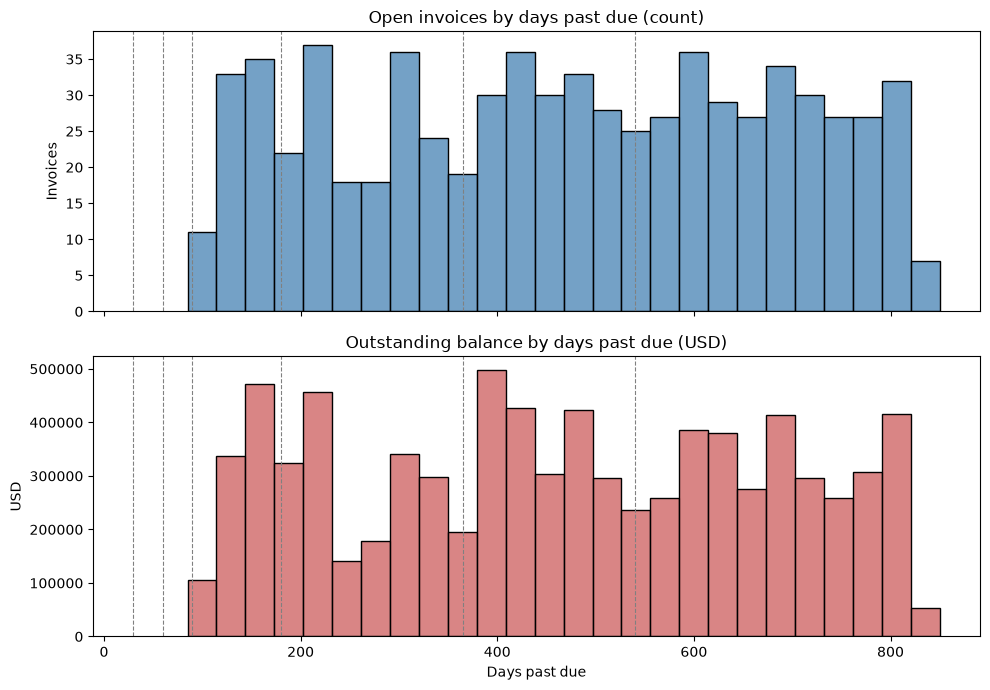

count    711.0
mean     469.0
std      214.0
min       85.0
25%      294.0
50%      475.0
75%      660.0
max      850.0
Name: days_past_due, dtype: float64


In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

sns.histplot(data=ar, x='days_past_due', binwidth=30, ax=axes[0], color='steelblue')
axes[0].set_title('Open invoices by days past due (count)')
axes[0].set_ylabel('Invoices')

sns.histplot(data=ar, x='days_past_due', weights='balance_usd', binwidth=30, ax=axes[1], color='indianred')
axes[1].set_title('Outstanding balance by days past due (USD)')
axes[1].set_ylabel('USD')
axes[1].set_xlabel('Days past due')

for ax in axes:
    for b in [30, 60, 90, 180, 365, 540]:
        ax.axvline(b, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print(ar['days_past_due'].describe().round(0))

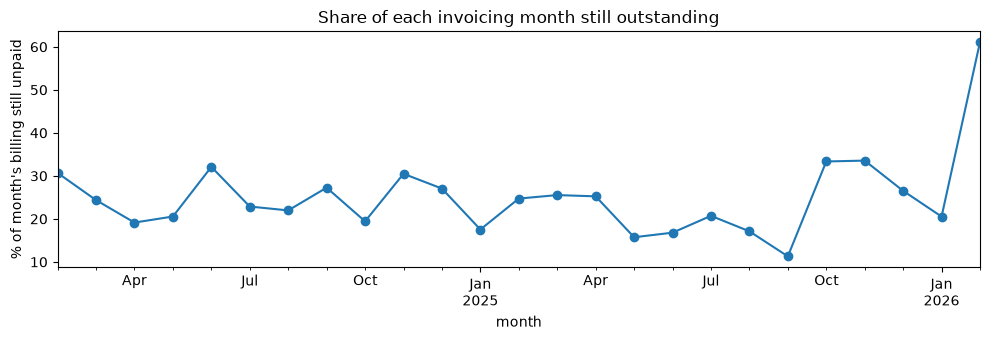

In [138]:
m = invoices[invoices['total'] > 0].copy()
m['month'] = m['invoice_date'].dt.to_period('M')
m['unpaid'] = (m['balance'] > 0.01) & (m['status'] != 'Written Off')
unpaid_rate = m.groupby('month').apply(lambda d: d.loc[d['unpaid'], 'balance_usd'].sum() / d['total_usd'].sum())

ax = (unpaid_rate * 100).plot(marker='o', figsize=(10, 3.5))
ax.set_ylabel('% of month\'s billing still unpaid')
ax.set_title('Share of each invoicing month still outstanding')
plt.tight_layout(); plt.show()

In [139]:
bins   = [0, 90, 180, 365, 730, 10_000]
labels = ['≤90', '91-180', '181-365', '1-2 years', '2+ years']

,invoices,balance_usd,share_%
bucket,,,
≤90,1,12729.0,0.0
91-180,90,1028332.0,13.0
181-365,160,1804483.0,22.0
1-2 years,367,4199334.0,52.0
2+ years,93,1035364.0,13.0


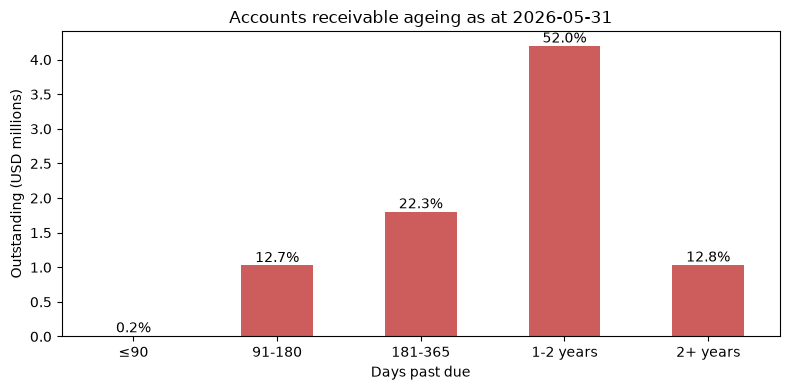

In [140]:
ar['bucket'] = pd.cut(ar['days_past_due'], bins=bins, labels=labels)

ageing = ar.groupby('bucket', observed=False).agg(invoices=('invoice_no', 'count'),
                                                  balance_usd=('balance_usd', 'sum'))
ageing['share_%'] = (ageing['balance_usd'] / ageing['balance_usd'].sum() * 100).round(1)
display(ageing.round(0))

ax = (ageing['balance_usd'] / 1e6).plot(kind='bar', color='indianred', figsize=(8, 4))
ax.set_ylabel('Outstanding (USD millions)')
ax.set_xlabel('Days past due')
ax.set_title(f'Accounts receivable ageing as at {as_of.date()}')
for i, (v, s) in enumerate(zip(ageing['balance_usd'] / 1e6, ageing['share_%'])):
    ax.text(i, v, f'{s}%', ha='center', va='bottom')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [141]:
by_client = (ar.groupby('client_id')
               .agg(open_invoices=('invoice_no', 'count'),
                    balance_usd=('balance_usd', 'sum'),
                    oldest_days=('days_past_due', 'max'))
               .merge(clients[['client_id', 'client_name']], on='client_id')
               .sort_values('balance_usd', ascending=False))
by_client['share_%'] = (by_client['balance_usd'] / by_client['balance_usd'].sum() * 100).round(1)
display(by_client.head(10).round(0))
print(f"Top 5 clients hold {by_client['share_%'].head(5).sum():.0f}% of outstanding AR")

,client_id,open_invoices,balance_usd,oldest_days,client_name,share_%
8,C2009,28,608393.0,800,Silverline Corp.,8.0
1,C2002,32,479899.0,812,Cedar Corp.,6.0
11,C2013,38,457294.0,817,Pioneer Corp.,6.0
15,C2017,27,399325.0,781,Crescent Group,5.0
3,C2004,38,393059.0,809,Keystone Group,5.0
4,C2005,15,386568.0,757,Summit Group,5.0
7,C2008,32,358878.0,849,Redwood LLC,4.0
10,C2012,37,335474.0,802,Quantum Ltd,4.0
31,C2034,25,330280.0,817,Lumen Holdings,4.0
6,C2007,23,321151.0,804,Atlas plc,4.0


Top 5 clients hold 29% of outstanding AR


In [142]:
status_age = ar.pivot_table(index='status', columns='bucket', values='balance_usd',
                            aggfunc='sum', fill_value=0, observed=False)
status_age['total'] = status_age.sum(axis=1)
display((status_age / 1e3).round(0))   # in USD thousands

bucket,≤90,91-180,181-365,1-2 years,2+ years,total
status,,,,,,
Disputed,0.0,146.0,308.0,928.0,207.0,1590.0
Outstanding,13.0,720.0,1154.0,2450.0,590.0,4928.0
Paid,0.0,0.0,29.0,82.0,1.0,112.0
Partially Paid,0.0,162.0,313.0,739.0,237.0,1450.0


In [143]:
bad_invoices = set(lines.loc[lines['dq_bad_rate_card'], 'invoice_no'])
overbilled = invoices['invoice_no'].isin(bad_invoices)
display(pd.crosstab(invoices['status'], overbilled, normalize='columns').round(3) * 100)

invoice_no,False,True
status,,
Disputed,3.6,5.8
Outstanding,14.8,9.1
Paid,68.0,75.2
Partially Paid,10.3,9.9
Written Off,3.3,0.0


In [144]:
pp_bad = invoices[invoices['invoice_no'].isin(bad_invoices) & (invoices['status'] == 'Partially Paid')].copy()
over_by_inv = lines.groupby('invoice_no')['overbilled'].sum()
pp_bad['overbilled'] = pp_bad['invoice_no'].map(over_by_inv)
display(pp_bad[['invoice_no', 'total', 'paid_amount', 'balance', 'overbilled']].head(10))

,invoice_no,total,paid_amount,balance,overbilled
304,INV-50305,47937.22,31367.95,16569.27,23490.180
306,INV-50307,32022.34,17960.53,14061.81,16387.740
449,INV-50450,9335.44,6865.27,2470.17,5289.363
476,INV-50477,14619.26,10677.42,3941.84,7819.200
494,INV-50495,27362.54,11128.03,16234.51,15687.270
497,INV-50498,22657.22,7739.61,14917.61,16684.218
549,INV-50550,13386.54,6879.41,6507.13,4098.564
595,INV-50596,15414.46,8296.77,7117.69,10135.638
597,INV-50598,13109.30,7464.29,5645.01,3461.625
2758,INV-52759,39643.42,29463.68,10179.74,27595.260


In [145]:
pp_bad = pp_bad.merge(clients[['client_id', 'vat_rate']], on='client_id', how='left', suffixes=('', '_c'))
pp_bad['withheld_vs_overbilled'] = pp_bad['balance'] / (pp_bad['overbilled'] * (1 + pp_bad['vat_rate']))
print(pp_bad['withheld_vs_overbilled'].describe().round(2))

count    12.00
mean      0.76
std       0.36
min       0.31
25%       0.49
50%       0.66
75%       0.98
max       1.37
Name: withheld_vs_overbilled, dtype: float64


On the 12 overbilled invoices that were partially paid, the unpaid balance ranged from 31% to 137% of the overcharge including VAT (median 66%). This shows no consistent relationship, so there is no evidence clients short-paid in response to the rate error. The overcharge has most likely gone unnoticed and may need to be refunded.

# DSO

The formula is open AR ÷ billing over a period × days in the period:

In [146]:
last_invoice = invoices['invoice_date'].max()
window = invoices[invoices['invoice_date'] > last_invoice - pd.DateOffset(years=1)]

ar_total = ar['balance_usd'].sum()
billing_12m = window['total_usd'].sum()
dso = ar_total / billing_12m * 365

print(f"Open AR: ${ar_total:,.0f}")
print(f"Billing, 12 months to {last_invoice.date()}: ${billing_12m:,.0f}")
print(f"DSO: {dso:.0f} days")

Open AR: $8,080,243
Billing, 12 months to 2026-02-10: $16,875,554
DSO: 175 days


In [147]:
w = window.merge(clients[['client_id']], on='client_id')
expected_dso = (w['payment_terms_days'] * w['total_usd']).sum() / w['total_usd'].sum()
print(f"Billing-weighted payment terms: {expected_dso:.0f} days")
print(f"DSO is {dso / expected_dso:.1f}x the agreed terms")

Billing-weighted payment terms: 29 days
DSO is 6.0x the agreed terms


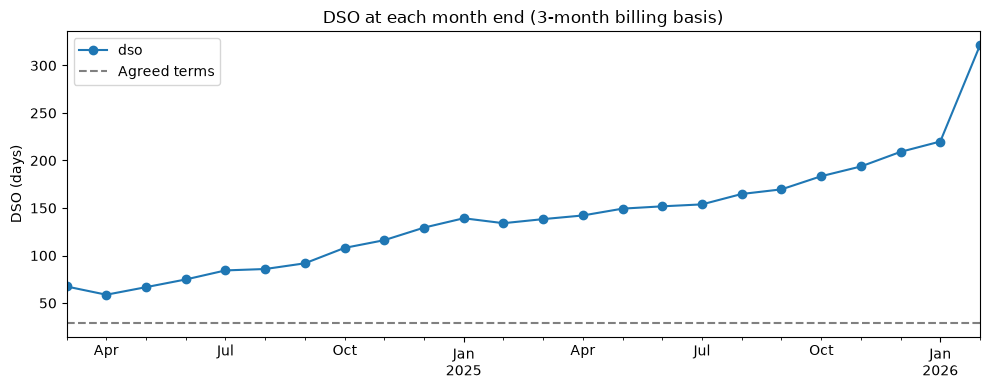

In [148]:
month_ends = pd.date_range('2024-03-31', last_invoice + pd.offsets.MonthEnd(0), freq='ME')
applied = payments[~payments['dq_orphan']]

rows = []
for d in month_ends:
    issued = invoices[invoices['invoice_date'] <= d]
    paid = applied[(applied['pay_date'] <= d) & applied['invoice_ref'].isin(issued['invoice_no'])]
    ar_d = issued['total_usd'].sum() - paid['amount_usd'].sum()
    billed_3m = invoices[(invoices['invoice_date'] > d - pd.DateOffset(months=3)) &
                         (invoices['invoice_date'] <= d)]['total_usd'].sum()
    rows.append({'month_end': d, 'ar_usd': ar_d, 'dso': ar_d / billed_3m * 91})

dso_trend = pd.DataFrame(rows)

ax = dso_trend.plot(x='month_end', y='dso', marker='o', legend=False, figsize=(10, 4))
ax.axhline(expected_dso, color='grey', linestyle='--', label='Agreed terms')
ax.set_ylabel('DSO (days)'); ax.set_xlabel('')
ax.set_title('DSO at each month end (3-month billing basis)')
ax.legend(); plt.tight_layout(); plt.show()

In [149]:
expected_ar = billing_12m * expected_dso / 365
print(f"AR at agreed terms: ${expected_ar:,.0f} | Excess tied up: ${ar_total - expected_ar:,.0f}")

AR at agreed terms: $1,338,087 | Excess tied up: $6,742,156


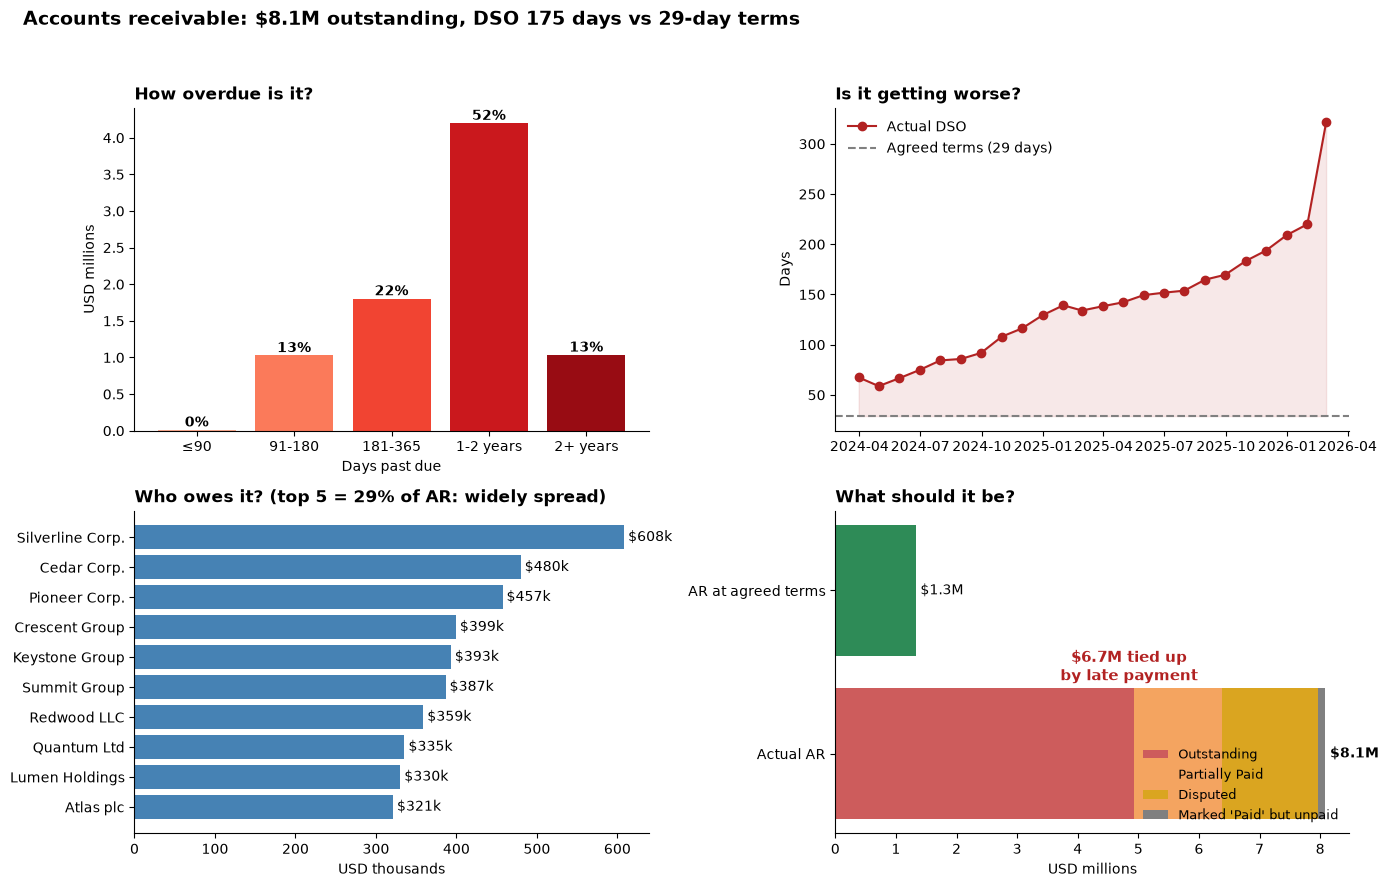

In [150]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Accounts receivable: ${ar_total/1e6:.1f}M outstanding, DSO {dso:.0f} days vs {expected_dso:.0f}-day terms',
             fontsize=14, fontweight='bold', x=0.02, ha='left')

# 1. Ageing: darker = older
ax = axes[0, 0]
vals = ageing['balance_usd'] / 1e6
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(vals)))
bars = ax.bar(ageing.index.astype(str), vals, color=colors)
for bar, share in zip(bars, ageing['share_%']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{share:.0f}%',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('How overdue is it?', loc='left', fontweight='bold')
ax.set_ylabel('USD millions')
ax.set_xlabel('Days past due')

# 2. DSO trend vs agreed terms
ax = axes[0, 1]
ax.plot(dso_trend['month_end'], dso_trend['dso'], marker='o', color='firebrick', label='Actual DSO')
ax.axhline(expected_dso, color='grey', linestyle='--', label=f'Agreed terms ({expected_dso:.0f} days)')
ax.fill_between(dso_trend['month_end'], expected_dso, dso_trend['dso'], color='firebrick', alpha=0.1)
ax.set_title('Is it getting worse?', loc='left', fontweight='bold')
ax.set_ylabel('Days')
ax.legend(frameon=False)

# 3. Top 10 debtors
ax = axes[1, 0]
top = by_client.head(10).iloc[::-1]
ax.barh(top['client_name'], top['balance_usd'] / 1e3, color='steelblue')
for y, v in enumerate(top['balance_usd'] / 1e3):
    ax.text(v, y, f' ${v:,.0f}k', va='center')
ax.set_title(f'Who owes it? (top 5 = {by_client["share_%"].head(5).sum():.0f}% of AR: widely spread)',
             loc='left', fontweight='bold')
ax.set_xlabel('USD thousands')

# 4. Actual AR vs AR at agreed terms, split by status
ax = axes[1, 1]
status_order = ['Outstanding', 'Partially Paid', 'Disputed', 'Paid']
status_colors = ['indianred', 'sandybrown', 'goldenrod', 'grey']
left = 0
for s, c in zip(status_order, status_colors):
    if s in status_age.index:
        v = status_age.loc[s, 'total'] / 1e6
        ax.barh('Actual AR', v, left=left, color=c, label=s if s != 'Paid' else "Marked 'Paid' but unpaid")
        left += v
ax.barh('AR at agreed terms', expected_ar / 1e6, color='seagreen')
ax.text(expected_ar / 1e6, 1, f' ${expected_ar/1e6:.1f}M', va='center')
ax.text(left, 0, f' ${left:.1f}M', va='center', fontweight='bold')
ax.annotate(f'${(ar_total - expected_ar)/1e6:.1f}M tied up\nby late payment',
            xy=(left * 0.6, 0.45), ha='center', fontsize=11, color='firebrick', fontweight='bold')
ax.set_title('What should it be?', loc='left', fontweight='bold')
ax.set_xlabel('USD millions')
ax.legend(frameon=False, loc='lower right', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('ar_summary.png', dpi=200, bbox_inches='tight')
plt.show()

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk', font_scale=0.9)   # 'talk' = larger fonts for slides
FIGSIZE = (11, 6)

def finish(fig, filename):
    sns.despine(left=True)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

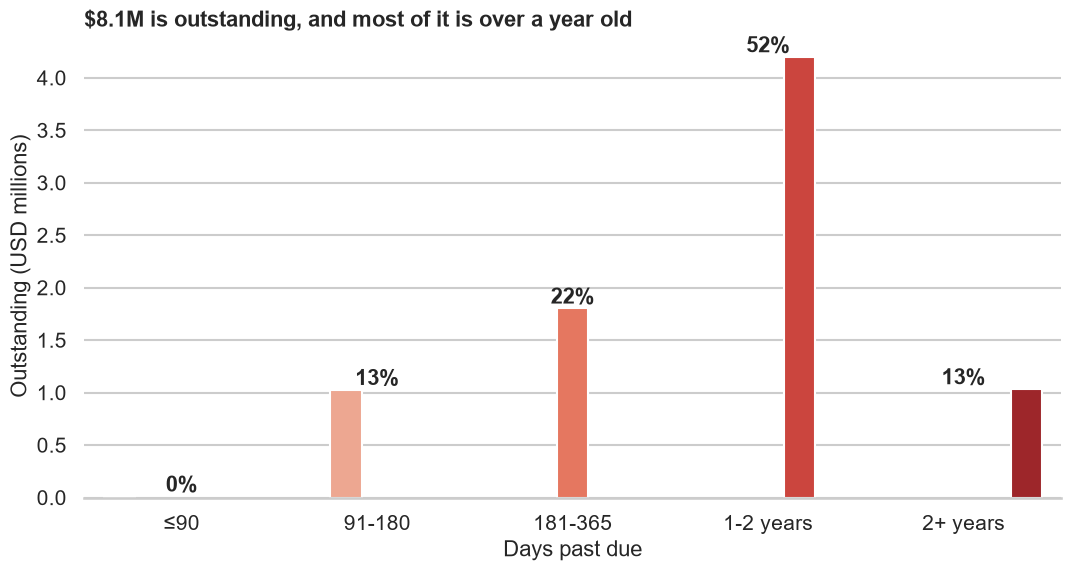

In [152]:
df = ageing.reset_index()
df['balance_m'] = df['balance_usd'] / 1e6

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(data=df, x='bucket', y='balance_m', hue='bucket', palette='Reds', legend=False, ax=ax)
for i, row in df.iterrows():
    ax.text(i, row['balance_m'], f"{row['share_%']:.0f}%", ha='center', va='bottom', fontweight='bold')
ax.set(xlabel='Days past due', ylabel='Outstanding (USD millions)')
ax.set_title(f'${ar_total/1e6:.1f}M is outstanding, and most of it is over a year old', loc='left', fontweight='bold')
finish(fig, 'fig1_ageing.png')

In [169]:
dso_plot = dso_trend[dso_trend['month_end'] <= '2025-12-31']

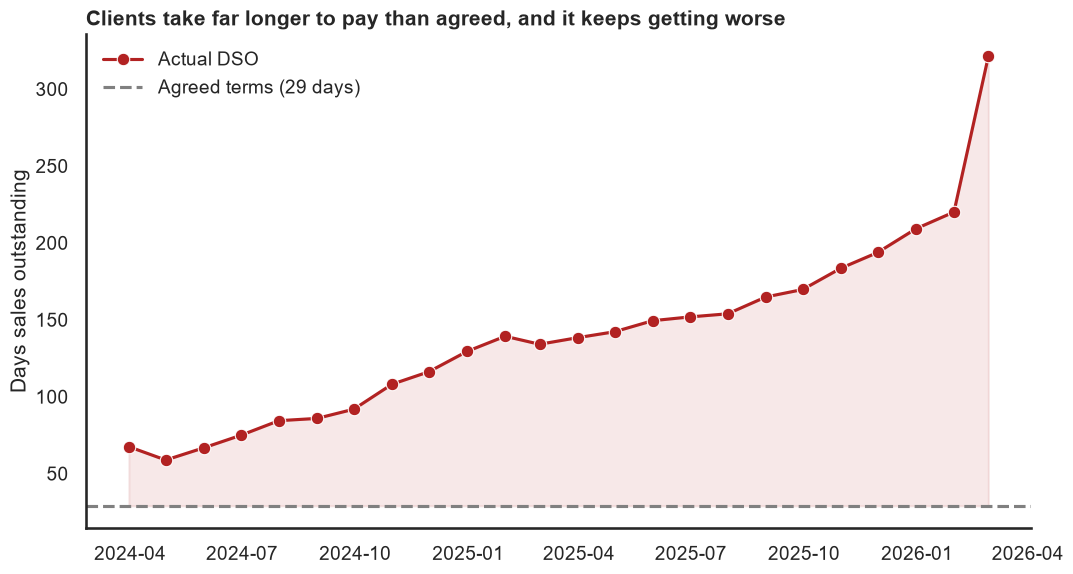

In [171]:
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.lineplot(data=dso_trend, x='month_end', y='dso', marker='o', color='firebrick', label='Actual DSO', ax=ax)
ax.axhline(expected_dso, color='grey', linestyle='--', label=f'Agreed terms ({expected_dso:.0f} days)')
ax.fill_between(dso_trend['month_end'], expected_dso, dso_trend['dso'], color='firebrick', alpha=0.1)
ax.set(xlabel='', ylabel='Days sales outstanding')
ax.set_title('Clients take far longer to pay than agreed, and it keeps getting worse', loc='left', fontweight='bold')
ax.legend(frameon=False)
finish(fig, 'fig2_dso_trend.png')

NameError: name 'top5_share' is not defined

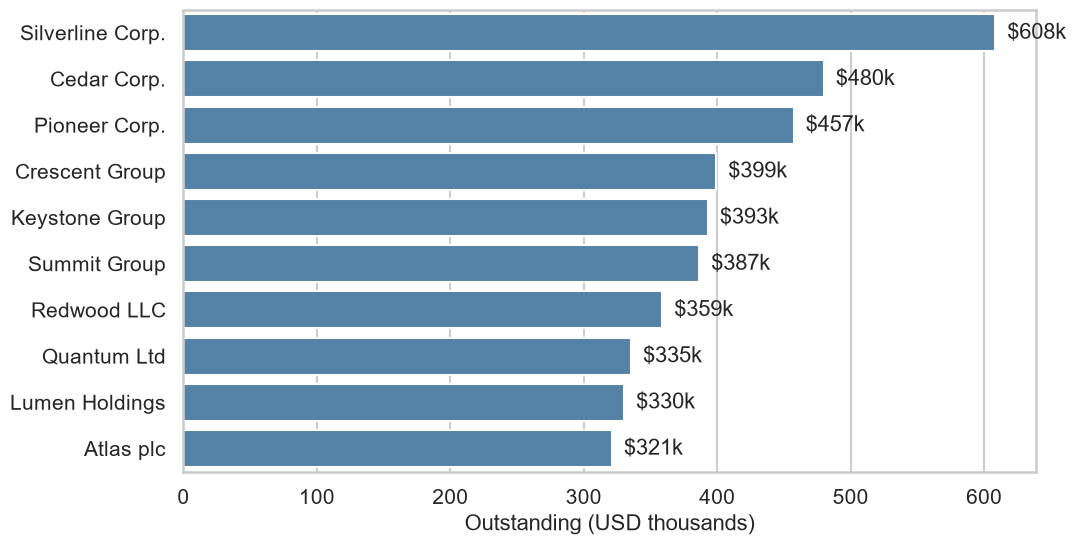

In [154]:
top = by_client.head(10).copy()
top['balance_k'] = top['balance_usd'] / 1e3

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(data=top, y='client_name', x='balance_k', color='steelblue', ax=ax)
for i, v in enumerate(top['balance_k']):
    ax.text(v, i, f'  ${v:,.0f}k', va='center')
ax.set(xlabel='Outstanding (USD thousands)', ylabel='')
ax.set_title(f'The debt is widely spread: top 5 clients hold only {top5_share:.0%}', loc='left', fontweight='bold')
finish(fig, 'fig3_top_debtors.png')

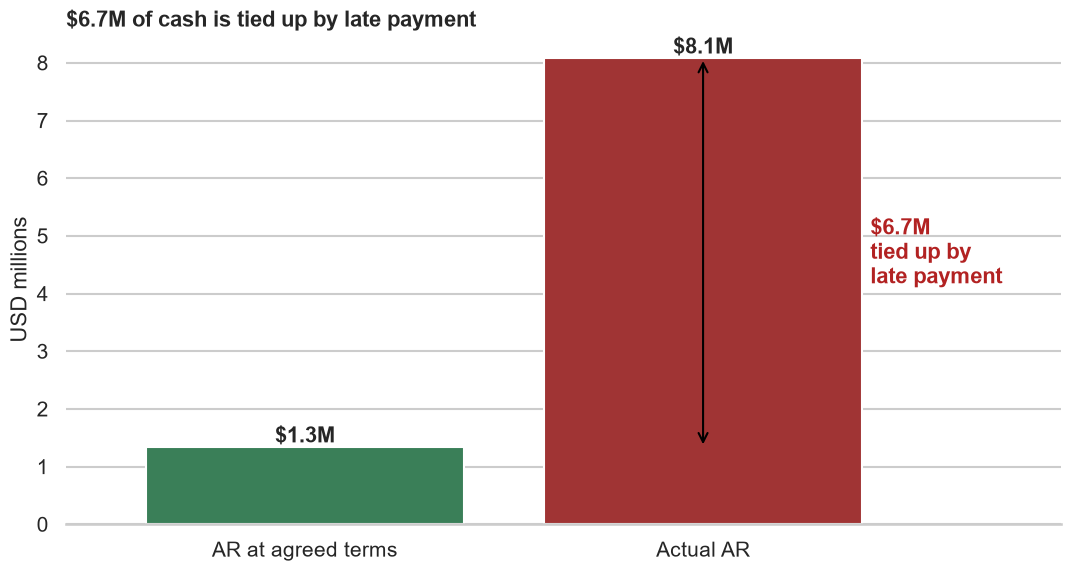

In [155]:
comp = pd.DataFrame({'label': ['AR at agreed terms', 'Actual AR'],
                     'usd_m': [expected_ar / 1e6, ar_total / 1e6]})

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(data=comp, x='label', y='usd_m', hue='label', palette=['seagreen', 'firebrick'], legend=False, ax=ax)
for i, v in enumerate(comp['usd_m']):
    ax.text(i, v, f'${v:.1f}M', ha='center', va='bottom', fontweight='bold')
ax.annotate('', xy=(1, ar_total / 1e6), xytext=(1, expected_ar / 1e6),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(1.42, (ar_total + expected_ar) / 2e6, f'${(ar_total - expected_ar)/1e6:.1f}M\ntied up by\nlate payment',
        va='center', fontweight='bold', color='firebrick')
ax.set(xlabel='', ylabel='USD millions')
ax.set_xlim(-0.6, 1.9)
ax.set_title(f'${(ar_total - expected_ar)/1e6:.1f}M of cash is tied up by late payment', loc='left', fontweight='bold')
finish(fig, 'fig4_cash_tied_up.png')

AR ageing & DSO: conclusion (as at 31 May 2026)

The firm has a serious collections problem. $8.1M is outstanding. At the agreed payment terms (29 days, weighted by billing), receivables would be about $1.3M, so $6.7M of cash is tied up by late payment. DSO is 175 days, six times the agreed terms.

It's systematic, not a few bad payers.

Balances are spread evenly across every age from 3 months to over 2 years, and a similar share of each month's billing is left unpaid.
DSO has risen steadily from [X] days in early 2024 to [Y] by early 2026.
The debt isn't concentrated: the top 5 clients hold only 29%, and every major debtor has invoices over two years old.

Most of the debt is old: about 65% is over a year overdue and 13% over two years, which is unlikely to be fully recovered.

The status field can't be trusted. $112k sits on invoices marked "Paid" that were never fully paid.

Recommendations

Chase debt under one year old first, starting with the largest undisputed balances. 61% of AR is undisputed "Outstanding" and has no obstacle to collection.
Resolve the $1.6M of disputed invoices as a separate workstream.
Provision for the older debt. Consider a bad-debt provision for the 1–2 year bucket, and review the 2+ year bucket for write-off.
Fix the invoice status process so collections can rely on it, and introduce routine dunning (reminders at 30, 60 and 90 days).
Refund the overbilling. We tested whether clients short-paid overbilled invoices and found no evidence of it. The overcharge has most likely gone unnoticed, so the firm should proactively correct it.

In [158]:

u = time[time['use_in_analysis']]
monthly = u.groupby(u['work_date'].dt.to_period('M'))['billable_hours'].sum()
monthly = monthly[monthly.index <= pd.Period('2025-12')]    # Jan 2026 has only a few days of data

def working_days(p):
    return np.busday_count(p.start_time.date(), (p.end_time + pd.Timedelta(days=1)).date())

ts = pd.DataFrame({'billable_hours': monthly})
ts['working_days'] = [working_days(p) for p in ts.index]
ts['hours_per_day'] = ts['billable_hours'] / ts['working_days']
ts['headcount'] = [((staff['hire_date'] <= p.end_time) &
                    (staff['termination_date'].isna() | (staff['termination_date'] >= p.start_time))).sum()
                   for p in ts.index]
ts['hours_per_person_day'] = ts['hours_per_day'] / ts['headcount']
display(ts.round(1))

,billable_hours,working_days,hours_per_day,headcount,hours_per_person_day
work_date,,,,,
2024-01,4187.5,23,182.1,60,3.0
2024-02,3725.7,21,177.4,60,3.0
2024-03,3924.5,21,186.9,60,3.1
2024-04,4102.7,22,186.5,60,3.1
2024-05,3989.7,23,173.5,60,2.9
2024-06,3524.9,20,176.2,59,3.0
2024-07,3890.2,23,169.1,57,3.0
2024-08,3539.0,22,160.9,57,2.8
2024-09,3513.1,21,167.3,56,3.0


In [159]:
x = np.arange(len(ts))
y = ts['billable_hours'].values
wd = ts['working_days'].values
train, test = slice(0, 18), slice(18, 24)       # train Jan-24..Jun-25, test Jul-25..Dec-25

coef = np.polyfit(x[train], ts['hours_per_day'].values[train], 1)
pred_trend = np.polyval(coef, x[test]) * wd[test]

mape = lambda pred: (np.abs(pred - y[test]) / y[test]).mean() * 100
results = pd.DataFrame({
    'model': ['Trend (per working day)', 'Naive (last month)', 'Average of last 6 months', 'Seasonal naive (same month last year)'],
    'MAPE_%': [mape(pred_trend), mape(np.repeat(y[17], 6)), mape(np.repeat(y[12:18].mean(), 6)), mape(y[6:12])],
}).round(1)
display(results)

,model,MAPE_%
0,Trend (per working day),3.3
1,Naive (last month),5.5
2,Average of last 6 months,10.2
3,Seasonal naive (same month last year),15.5


In [160]:
coef = np.polyfit(x, ts['hours_per_day'].values, 1)
fitted = np.polyval(coef, x) * wd
resid_pct = (y - fitted) / fitted
band = 1.96 * resid_pct.std()                   # ~95% band, as a % of the forecast

future = pd.period_range('2026-01', periods=6, freq='M')
fc = pd.DataFrame(index=future)
fc['working_days'] = [working_days(p) for p in future]
fc['forecast'] = np.polyval(coef, np.arange(24, 30)) * fc['working_days']
fc['lower'] = fc['forecast'] * (1 - band)
fc['upper'] = fc['forecast'] * (1 + band)
display(fc.round(0))
print(f"Trend: {coef[0] * 12 / ts['hours_per_day'][:12].mean() * 100:.0f}% per year")

,working_days,forecast,lower,upper
2026-01,22,3003.0,2803.0,3203.0
2026-02,20,2690.0,2511.0,2870.0
2026-03,22,2916.0,2721.0,3110.0
2026-04,22,2872.0,2681.0,3064.0
2026-05,21,2700.0,2520.0,2880.0
2026-06,22,2785.0,2599.0,2971.0


Trend: -14% per year


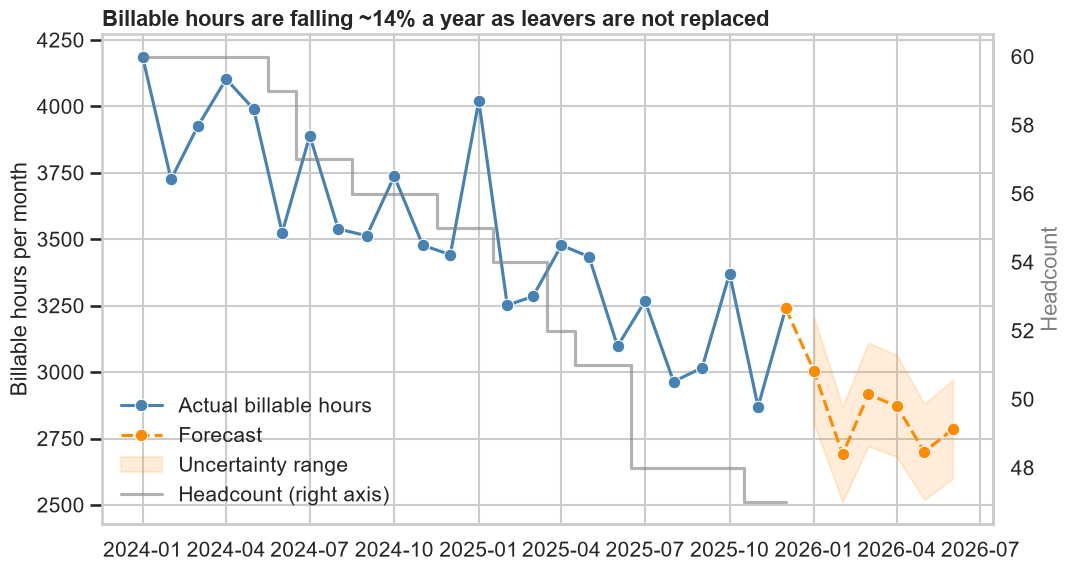

In [162]:
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.lineplot(x=hist.index, y=hist.values, marker='o', color='steelblue', label='Actual billable hours', ax=ax)

# prepend the last actual point so the forecast line connects
f_line = pd.concat([pd.Series([hist.iloc[-1]], index=[hist.index[-1]]), f['forecast']])
sns.lineplot(x=f_line.index, y=f_line.values, marker='o', linestyle='--', color='darkorange', label='Forecast', ax=ax)
ax.fill_between(f.index, f['lower'], f['upper'], color='darkorange', alpha=0.15, label='Uncertainty range')

ax2 = ax.twinx()
ax2.step(hist.index, ts['headcount'].values, where='mid', color='grey', alpha=0.6, label='Headcount (right axis)')
ax2.set_ylabel('Headcount', color='grey'); ax2.grid(False)
sns.despine(ax=ax2, left=True, right=False)

# one combined legend for both axes
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, loc='lower left')

ax.set(xlabel='', ylabel='Billable hours per month')
ax.set_title('Billable hours are falling ~14% a year as leavers are not replaced', loc='left', fontweight='bold')
fig.tight_layout()
fig.savefig('fig6_forecast.png', dpi=200, bbox_inches='tight')
plt.show()

- Billable hours fell from ~4,000 to ~3,100 per month over 2024–25
- Headcount dropped from 60 to 47, while hours per person stayed flat: the decline is about capacity, not demand
- The forecast for H1 2026 is ~2,700–3,000 hours/month (the zig-zag reflects working days per month)
- Recommendation: backfill leavers or plan for reduced billing capacity

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

NAVY, RED, ORANGE, GREY, GREEN = '#1f3b5c', '#c0392b', '#e67e22', '#9e9e9e', '#2e8b57'
FIGSIZE = (11, 6)

sns.set_theme(style='white', context='talk', font_scale=0.85, rc={
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y', 'grid.color': '#eeeeee',
})

def titled(ax, title, subtitle=None):
    """Bold takeaway title, with an optional grey subtitle underneath."""
    ax.set_title(title, loc='left', fontweight='bold', fontsize=16, pad=30 if subtitle else 12)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=11, color='#666666', va='bottom')

def finish(fig, filename):
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

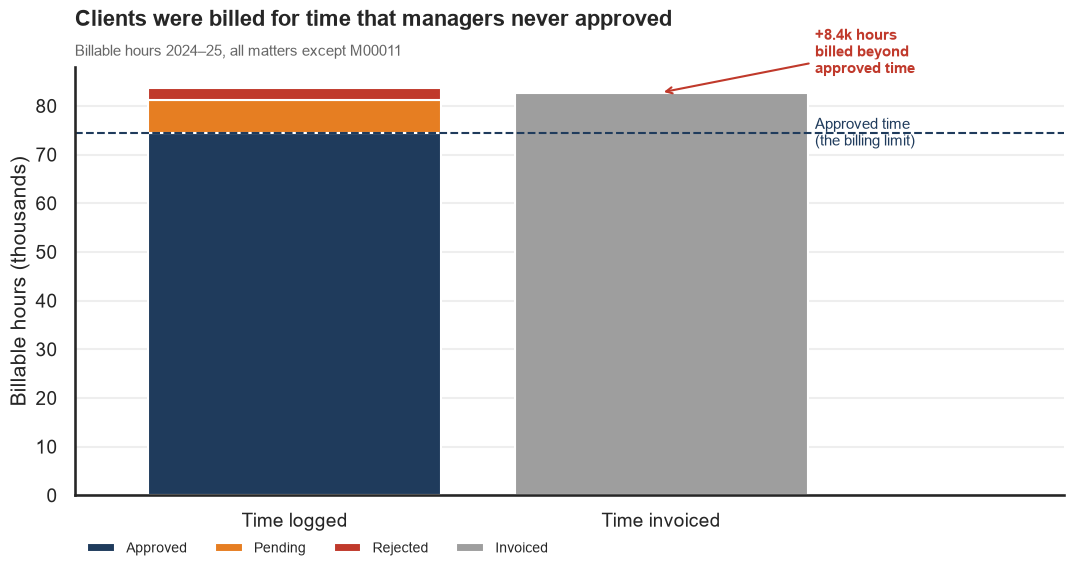

In [165]:
tot = rest[['Approved', 'Pending', 'Rejected', 'invoiced_hours']].sum() / 1e3   # thousands of hours, excl. M00011

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar('Time logged', tot['Approved'], color=NAVY, label='Approved')
ax.bar('Time logged', tot['Pending'], bottom=tot['Approved'], color=ORANGE, label='Pending')
ax.bar('Time logged', tot['Rejected'], bottom=tot['Approved'] + tot['Pending'], color=RED, label='Rejected')
ax.bar('Time invoiced', tot['invoiced_hours'], color=GREY, label='Invoiced')

ax.axhline(tot['Approved'], color=NAVY, linestyle='--', linewidth=1.5)
ax.text(1.42, tot['Approved'], 'Approved time\n(the billing limit)', va='center', color=NAVY, fontsize=11)
over = tot['invoiced_hours'] - tot['Approved']
ax.annotate(f'+{over:.1f}k hours\nbilled beyond\napproved time', xy=(1, tot['invoiced_hours']),
            xytext=(1.42, tot['invoiced_hours'] + 4), color=RED, fontweight='bold', fontsize=11,
            arrowprops=dict(arrowstyle='->', color=RED))

ax.set(ylabel='Billable hours (thousands)', xlim=(-0.6, 2.1))
ax.legend(frameon=False, loc='upper left', ncols=4, fontsize=10, bbox_to_anchor=(0, -0.08))
titled(ax, 'Clients were billed for time that managers never approved',
       'Billable hours 2024–25, all matters except M00011')
finish(fig, 'slide2_approval.png')

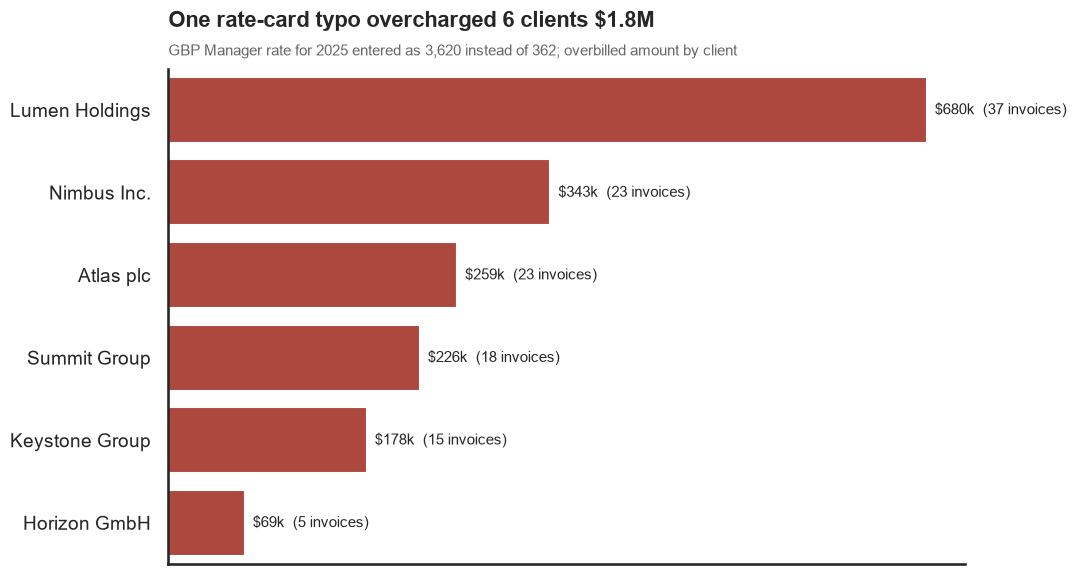

In [166]:
ob_client = (bad.merge(invoices[['invoice_no', 'client_id']], on='invoice_no')
                .groupby('client_id')
                .agg(overbilled_usd=('overbilled_usd', 'sum'), n_invoices=('invoice_no', 'nunique'))
                .join(clients.set_index('client_id')['client_name'])
                .sort_values('overbilled_usd', ascending=False)
                .reset_index())

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(data=ob_client, y='client_name', x=ob_client['overbilled_usd'] / 1e3, color=RED, ax=ax)
for i, row in ob_client.iterrows():
    ax.text(row['overbilled_usd'] / 1e3, i, f"  ${row['overbilled_usd']/1e3:,.0f}k  ({row['n_invoices']} invoices)",
            va='center', fontsize=11)
ax.set(xlabel='', ylabel='', xticks=[])
ax.grid(False)
titled(ax, f"One rate-card typo overcharged 6 clients ${ob_client['overbilled_usd'].sum()/1e6:.1f}M",
       'GBP Manager rate for 2025 entered as 3,620 instead of 362; overbilled amount by client')
finish(fig, 'slide3_overbilling.png')

,finding,usd,usd_m
0,Cash tied up by late payment,6742155.79,6.74
1,Overbilling (rate-card typo),1753674.29,1.75
2,Rejected time billed,682814.77,0.68
3,Overpayments to refund,139017.07,0.14
4,Unapplied cash,107142.96,0.11


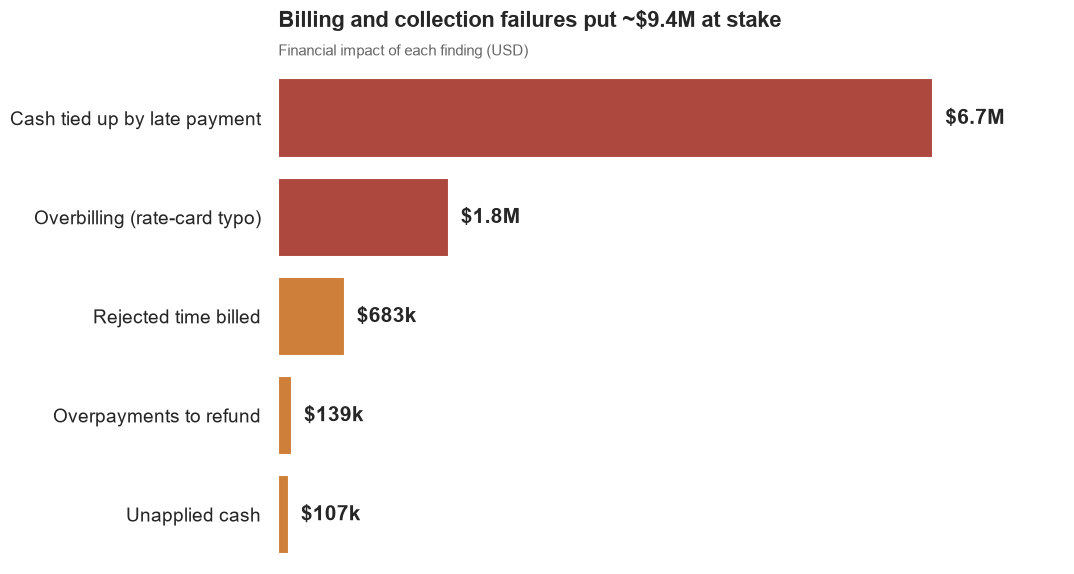

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

NAVY, RED, ORANGE, GREY = '#1f3b5c', '#c0392b', '#e67e22', '#9e9e9e'
sns.set_theme(style='white', context='talk', font_scale=0.85,
              rc={'axes.spines.top': False, 'axes.spines.right': False})

# --- values ---
REJECTED_VALUE = (rej_val['billable_hours'] * rej_val['usd_per_hour']).sum()

op = payments[payments['dq_overpayment']]
OVERPAID_EXCESS = ((op['amount'] - op['total']) * op['usd_per_unit']).sum()

impact = pd.DataFrame({
    'finding': ['Cash tied up by late payment',
                'Overbilling (rate-card typo)',
                'Rejected time billed',
                'Overpayments to refund',
                'Unapplied cash'],
    'usd': [ar_total - expected_ar,
            bad['overbilled_usd'].sum(),
            REJECTED_VALUE,
            OVERPAID_EXCESS,
            payments.loc[payments['dq_orphan'], 'amount_usd'].sum()],
}).sort_values('usd', ascending=False).reset_index(drop=True)
impact['usd_m'] = impact['usd'] / 1e6
display(impact.round(2))     # sanity check before plotting

# --- chart ---
fig, ax = plt.subplots(figsize=(11, 6))
colors = [RED if v >= 1 else ORANGE for v in impact['usd_m']]
sns.barplot(data=impact, y='finding', x='usd_m', hue='finding', palette=colors, legend=False, ax=ax)

for i, v in enumerate(impact['usd_m']):
    label = f'${v:.1f}M' if v >= 1 else f'${v*1000:,.0f}k'
    ax.text(v, i, f'  {label}', va='center', fontweight='bold')

total = impact['usd_m'].sum()
ax.set(xlabel='', ylabel='', xticks=[])
ax.set_xlim(0, impact['usd_m'].max() * 1.2)          # room for the labels
ax.set_title(f'Billing and collection failures put ~${total:.1f}M at stake',
             loc='left', fontweight='bold', fontsize=16, pad=30)
ax.text(0, 1.02, 'Financial impact of each finding (USD)', transform=ax.transAxes,
        fontsize=11, color='#666666', va='bottom')
sns.despine(left=True, bottom=True)

fig.tight_layout()
fig.savefig('slide_money_at_stake.png', dpi=200, bbox_inches='tight')
plt.show()